# V4 vs V5 Training Strategy Comparison

**Purpose:** Compare the v4 training strategy against v5 candidates on the 4 clean tuning folds.  
**Important:** NO production model artifacts are used — models are trained fresh per fold to avoid leakage.  
WC 2022 is held out from all training here (it is the final held-out test set).

**Tuning folds:** WC 2014, WC 2018, Euro 2024, Copa 2024  
**Holdout (never touched here):** WC 2022

## What this notebook tests
1. **Baseline** – V4 features + competition weights + `floor(λ+0.1)` rule  
2. **Score conversion** – DC grid argmax vs `floor(λ+0.1)` on the same OOF lambdas  
3. **Features** – Drop `matches_played_before`, add `competition_importance`, `rest_diff`, `tournament_key_numeric`, tournament goals rate diffs  
4. **Weighting** – Decay rate × competition/temporal blend sweep  
5. **Combined V5 candidate** – best feature set + best weights + DC grid  
6. **Tournament lambda blending** – in-tournament scoring rate blend weight sweep

## 0 · Setup

In [1]:
import sys, os
# Run from project root so src imports work
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded.')

Working directory: c:\Users\yuval\WC_Predictor
Libraries loaded.


In [2]:
from src.evaluation.protocol import (
    DATASET_PATH, TUNING_FOLDS, HOLDOUT, TARGET_COLS, MAJOR_TOURNAMENTS,
    load_and_prepare_dataset,
    generate_oof_lambdas,
    aggregate_oof_results,
    compute_fold_metrics,
    v4_score_fn, v4_probs_fn,
)
from src.models.score_grid import (
    fit_calibration_params,
    make_score_fn,
    dixon_coles_grid,
    win_draw_loss_from_grid,
)
from src.models.ensemble import EnsembleGoalModel
from src.models.lgbm_model import LGBMGoalModel
from src.models.xgb_model import XGBGoalModel
from src.models.weighting import apply_combined_weighting
from src.features.feature_columns import FEATURE_COLS, FEATURE_COLS_V5

print('Project modules loaded.')

Project modules loaded.


## 1 · Load dataset & verify folds

In [3]:
df = load_and_prepare_dataset(DATASET_PATH)
print(f'Total rows: {len(df)}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print()

# Verify fold counts
print('Fold sizes:')
for comp, year in TUNING_FOLDS:
    n = ((df['competition'] == comp) & (df['tournament_year'] == year)).sum()
    print(f'  {comp} {year}: {n} matches')

holdout_comp, holdout_year = HOLDOUT
n_holdout = ((df['competition'] == holdout_comp) & (df['tournament_year'] == holdout_year)).sum()
print(f'  HOLDOUT {holdout_comp} {holdout_year}: {n_holdout} matches (NEVER touched here)')

Total rows: 21655
Date range: 2004-01-01 → 2026-06-08

Fold sizes:
  World Cup 2014: 64 matches
  World Cup 2018: 64 matches
  European Championship 2024: 51 matches
  Copa America 2024: 32 matches
  HOLDOUT World Cup 2022: 64 matches (NEVER touched here)


In [4]:
# Verify new V5 features were added
new_v5_cols = ['competition_importance', 'tournament_key_numeric', 'rest_diff',
               'tournament_goals_for_per_match_diff', 'tournament_goals_against_per_match_diff']
for col in new_v5_cols:
    present = col in df.columns
    sample = df[col].describe() if present else 'MISSING'
    print(f'{col}: {"OK" if present else "MISSING"}')

print()
print('tournament_key_numeric distribution:')
print(df['tournament_key_numeric'].value_counts().sort_index())

print()
print('competition_importance distribution (top 10):')
print(df.groupby('competition')['competition_importance'].first().sort_values(ascending=False).head(10))

competition_importance: OK
tournament_key_numeric: OK
rest_diff: OK
tournament_goals_for_per_match_diff: OK
tournament_goals_against_per_match_diff: OK

tournament_key_numeric distribution:
tournament_key_numeric
1     320
2     929
3    5070
4    3829
5    4234
6    7273
Name: count, dtype: int64

competition_importance distribution (top 10):
competition
World Cup                             4.0000
European Championship                 3.0000
Copa America                          3.0000
African Nations Cup                   3.0000
World Cup and African Cup qualifier   2.0000
Copa America qualifier                2.0000
European Championship qualifier       2.0000
World Cup & Oce Cup q & S Pac G       2.0000
World Cup and Asian Cup qualifier     2.0000
African Nations Cup qualifier         2.0000
Name: competition_importance, dtype: float64


In [5]:
# Verify tournament goals rate features are 0 for non-major rows
major_mask = df['competition'].isin(MAJOR_TOURNAMENTS)
non_major_gf = df.loc[~major_mask, 'tournament_goals_for_per_match_diff']
assert (non_major_gf == 0).all(), 'Non-major rows should have 0 tournament rate features!'

# Check major tournament rows have non-zero values after matchday 1
major_df = df[major_mask].copy()
later_matches = major_df[major_df['team_a_tournament_matches_played'] >= 1]
nonzero_rate = (later_matches['tournament_goals_for_per_match_diff'] != 0).mean()
print(f'Major tournament rows with >=1 match played that have nonzero rate diff: {nonzero_rate:.1%}')

# Spot-check: WC 2022 match day 3 rows
wc22 = df[(df['competition'] == 'World Cup') & (df['tournament_year'] == 2022)]
print('\nWC 2022 tournament_goals_for_per_match_diff sample (sorted by matches played):')
print(wc22[['team_A', 'team_B', 'team_a_tournament_matches_played', 
            'tournament_goals_for_per_match_diff', 'tournament_goals_against_per_match_diff']]
      .sort_values('team_a_tournament_matches_played').head(8))

Major tournament rows with >=1 match played that have nonzero rate diff: 80.9%

WC 2022 tournament_goals_for_per_match_diff sample (sorted by matches played):
            team_A      team_B  team_a_tournament_matches_played  \
17860        Qatar     Ecuador                                 0   
17878       Brazil      Serbia                                 0   
17875  Switzerland    Cameroon                                 0   
17874     Portugal       Ghana                                 0   
17873  South Korea     Uruguay                                 0   
17871      Croatia     Morocco                                 0   
17870        Japan     Germany                                 0   
17869        Spain  Costa Rica                                 0   

       tournament_goals_for_per_match_diff  \
17860                               0.0000   
17878                               0.0000   
17875                               0.0000   
17874                               0.0000  

In [ ]:
wc22

## 2 · Helper functions

In [6]:
def make_ensemble():
    """Fresh ensemble model factory — NO production artifacts used."""
    return EnsembleGoalModel(
        [LGBMGoalModel(), XGBGoalModel()],
        weights=[0.9, 0.1],
    )


def make_weights_fn(decay_rate=1.0, comp_blend=0.7, ref_year=2026):
    """Build a sample-weight function with given decay/blend settings."""
    def weights_fn(train_df):
        return apply_combined_weighting(
            train_df,
            apply_decay=(decay_rate < 1.0),
            decay_rate=decay_rate,
            reference_year=ref_year,
            competition_weight=comp_blend,
            temporal_weight=1.0 - comp_blend,
        )
    return weights_fn


def run_strategy(
    label, feature_cols, weights_fn=None,
    alpha=0.0, et_scale=30/90,
    use_dc=True,
):
    """
    Run OOF evaluation for a given strategy. Returns a result dict.
    
    - Trains a fresh model per fold (no leakage)
    - Scores OOF lambdas with v4 floor rule AND v5 DC grid
    - Returns calibration params + both sets of metrics
    """
    print(f'\n[{label}] Generating OOF lambdas ({len(feature_cols)} features)...')
    
    oof_df = generate_oof_lambdas(
        df=df,
        model_factory=make_ensemble,
        feature_cols=feature_cols,
        weights_fn=weights_fn,
        folds=TUNING_FOLDS,
        holdout=HOLDOUT,
    )
    
    la = oof_df['pred_lambda_a'].values
    lb = oof_df['pred_lambda_b'].values
    ga = oof_df['goals_A'].values.astype(int)
    gb = oof_df['goals_B'].values.astype(int)
    
    # V4 floor rule
    v4_res = aggregate_oof_results(oof_df, v4_score_fn, v4_probs_fn)
    
    # Fit calibration
    calib = fit_calibration_params(la, lb, ga, gb)
    
    # V5 DC grid with scale calibration
    sfn, pfn = make_score_fn(
        rho=calib['rho'],
        scale_c=calib['scale_c'],
        alpha=alpha,
        knockout=False,
    )
    v5_res = aggregate_oof_results(oof_df, sfn, pfn)
    
    # V5 DC grid with affine calibration
    sfn_aff, pfn_aff = make_score_fn(
        rho=calib['rho'],
        affine_a=calib.get('affine_a'),
        affine_b=calib.get('affine_b'),
        alpha=alpha,
        knockout=False,
    )
    v5_aff_res = aggregate_oof_results(oof_df, sfn_aff, pfn_aff)
    
    def _m(res):
        o = res['overall']
        return {
            'exact_acc_%': round(o['exact_score_accuracy'] * 100, 2),
            'outcome_acc_%': round(o['outcome_accuracy'] * 100, 2),
            'pred_draw_%': round(o['predicted_draw_rate'] * 100, 2),
            'actual_draw_%': round(o['actual_draw_rate'] * 100, 2),
            'n_pred_non_basic': o['n_pred_non_basic'],
            'rps': round(o.get('rps', float('nan')), 4),
        }
    
    result = {
        'label': label,
        'n_features': len(feature_cols),
        'calibration': calib,
        'v4_floor': _m(v4_res),
        'v5_dc_scale': _m(v5_res),
        'v5_dc_affine': _m(v5_aff_res),
        'per_fold_v5_scale': v5_res['per_fold'],
        'oof_df': oof_df,
    }
    
    print(f'  Calib: scale_c={calib["scale_c"]:.3f}  rho={calib["rho"]:.3f}  '
          f'affine_b={calib.get("affine_b", 1):.3f}')
    print(f'  V4 floor:      exact={result["v4_floor"]["exact_acc_%"]:5.2f}%  '
          f'outcome={result["v4_floor"]["outcome_acc_%"]:5.2f}%  '
          f'draw={result["v4_floor"]["pred_draw_%"]:5.2f}%')
    print(f'  V5 DC scale:   exact={result["v5_dc_scale"]["exact_acc_%"]:5.2f}%  '
          f'outcome={result["v5_dc_scale"]["outcome_acc_%"]:5.2f}%  '
          f'draw={result["v5_dc_scale"]["pred_draw_%"]:5.2f}%')
    print(f'  V5 DC affine:  exact={result["v5_dc_affine"]["exact_acc_%"]:5.2f}%  '
          f'outcome={result["v5_dc_affine"]["outcome_acc_%"]:5.2f}%  '
          f'draw={result["v5_dc_affine"]["pred_draw_%"]:5.2f}%')
    
    return result


all_results = []  # accumulate across sections
print('Helpers ready.')

Helpers ready.


## 3 · V4 Baseline
V4 feature set, competition weights only (no temporal decay), floor(λ+0.1) rule.

In [7]:
r_v4 = run_strategy(
    label='V4_baseline',
    feature_cols=FEATURE_COLS,
    weights_fn=make_weights_fn(decay_rate=1.0, comp_blend=0.7),
)
all_results.append(r_v4)


[V4_baseline] Generating OOF lambdas (20 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=0.967  rho=-0.339  affine_b=0.994
  V4 floor:      exact=18.48%  outcome=83.41%  draw=14.69%
  V5 DC scale:   exact=21.80%  outcome=88.15%  draw=35.55%
  V5 DC affine:  exact=21.80%  outcome=88.15%  draw=35.55%


In [8]:
# Per-fold breakdown for V4 baseline
print('V4 baseline — per-fold exact accuracy (DC scale grid, same OOF lambdas):')
for fold_name, m in r_v4['per_fold_v5_scale'].items():
    print(f'  {fold_name}: exact={m["exact_score_accuracy"]*100:.2f}%  '
          f'draw_pred={m["predicted_draw_rate"]*100:.1f}%  '
          f'draw_actual={m["actual_draw_rate"]*100:.1f}%')

V4 baseline — per-fold exact accuracy (DC scale grid, same OOF lambdas):
  Copa America 2024: exact=31.25%  draw_pred=31.2%  draw_actual=28.1%
  European Championship 2024: exact=23.53%  draw_pred=49.0%  draw_actual=33.3%
  World Cup 2014: exact=15.62%  draw_pred=34.4%  draw_actual=20.3%
  World Cup 2018: exact=21.88%  draw_pred=28.1%  draw_actual=20.3%


## 4 · Score Conversion Comparison
Same model (V4 features + V4 weights), different decision rules applied to OOF lambdas.

In [9]:
# Reuse OOF lambdas from v4 baseline — just test different alpha values
oof_df_v4 = r_v4['oof_df']
calib_v4 = r_v4['calibration']

conversion_rows = []

for alpha in [0.0, 0.05, 0.10, 0.20]:
    sfn, pfn = make_score_fn(rho=calib_v4['rho'], scale_c=calib_v4['scale_c'], alpha=alpha)
    res = aggregate_oof_results(oof_df_v4, sfn, pfn)
    o = res['overall']
    conversion_rows.append({
        'conversion': f'DC_grid_alpha={alpha}',
        'exact_acc_%': round(o['exact_score_accuracy'] * 100, 2),
        'outcome_acc_%': round(o['outcome_accuracy'] * 100, 2),
        'pred_draw_%': round(o['predicted_draw_rate'] * 100, 2),
        'n_pred_non_basic': o['n_pred_non_basic'],
    })

# V4 floor rule for comparison
for threshold in [0.9, 1.0]:
    floor_fn = lambda la, lb, t=threshold: v4_score_fn(la, lb, t)
    res = aggregate_oof_results(oof_df_v4, floor_fn, v4_probs_fn)
    o = res['overall']
    conversion_rows.append({
        'conversion': f'floor_threshold={threshold}',
        'exact_acc_%': round(o['exact_score_accuracy'] * 100, 2),
        'outcome_acc_%': round(o['outcome_accuracy'] * 100, 2),
        'pred_draw_%': round(o['predicted_draw_rate'] * 100, 2),
        'n_pred_non_basic': o['n_pred_non_basic'],
    })

conv_df = pd.DataFrame(conversion_rows)
print('Score conversion comparison (V4 features + weights, OOF lambdas):')
print(conv_df.to_string(index=False))

Score conversion comparison (V4 features + weights, OOF lambdas):
         conversion  exact_acc_%  outcome_acc_%  pred_draw_%  n_pred_non_basic
  DC_grid_alpha=0.0      21.8000        88.1500      35.5500                 0
 DC_grid_alpha=0.05      22.7500        89.5700      33.1800                 0
  DC_grid_alpha=0.1      22.2700        90.5200      29.3800                 0
  DC_grid_alpha=0.2      22.7500        91.4700      25.5900                 1
floor_threshold=0.9      18.4800        83.4100      14.6900                 1
floor_threshold=1.0      17.5400        80.0900       9.4800                 1


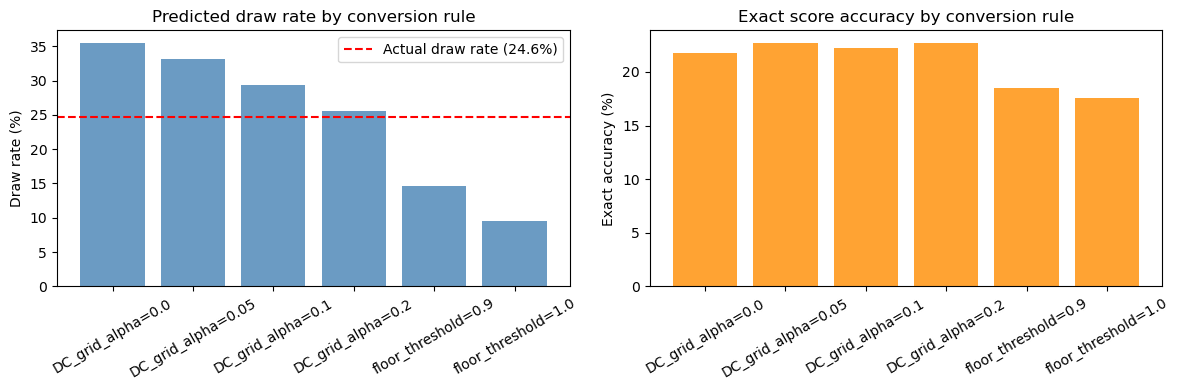

In [10]:
# Visualise draw rate: actual vs predicted by conversion method
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Draw rates
actual_draw = r_v4['v4_floor']['actual_draw_%']
ax = axes[0]
ax.bar(conv_df['conversion'], conv_df['pred_draw_%'], color='steelblue', alpha=0.8)
ax.axhline(actual_draw, color='red', linestyle='--', label=f'Actual draw rate ({actual_draw:.1f}%)')
ax.set_title('Predicted draw rate by conversion rule')
ax.set_ylabel('Draw rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()

# Exact accuracy
ax2 = axes[1]
ax2.bar(conv_df['conversion'], conv_df['exact_acc_%'], color='darkorange', alpha=0.8)
ax2.set_title('Exact score accuracy by conversion rule')
ax2.set_ylabel('Exact accuracy (%)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5 · Feature Set Comparison
V4 features vs V5 features (using same weights and DC grid scoring).

In [11]:
print('V4 features:', len(FEATURE_COLS))
print('V5 features:', len(FEATURE_COLS_V5))
print()
dropped = set(FEATURE_COLS) - set(FEATURE_COLS_V5)
added = set(FEATURE_COLS_V5) - set(FEATURE_COLS)
print('Dropped:', dropped)
print('Added:', added)

V4 features: 20
V5 features: 23

Dropped: {'team_b_matches_played_before', 'team_a_matches_played_before'}
Added: {'tournament_goals_against_per_match_diff', 'tournament_key_numeric', 'competition_importance', 'tournament_goals_for_per_match_diff', 'rest_diff'}


In [12]:
r_v5_feats = run_strategy(
    label='V5_features_no_decay',
    feature_cols=FEATURE_COLS_V5,
    weights_fn=make_weights_fn(decay_rate=1.0, comp_blend=0.7),
)
all_results.append(r_v5_feats)


[V5_features_no_decay] Generating OOF lambdas (23 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=1.002  rho=-0.319  affine_b=0.982
  V4 floor:      exact=20.38%  outcome=81.99%  draw=11.37%
  V5 DC scale:   exact=19.43%  outcome=87.20%  draw=36.49%
  V5 DC affine:  exact=19.91%  outcome=86.73%  draw=36.97%


In [13]:
# Subsets: test each new feature group in isolation against V4 baseline
# (comment out if runtime is too long)

v4_plus_compimportance = FEATURE_COLS + ['competition_importance', 'tournament_key_numeric']
v4_plus_rest = FEATURE_COLS + ['rest_diff']
v4_plus_tournament_rates = FEATURE_COLS + ['tournament_goals_for_per_match_diff', 
                                             'tournament_goals_against_per_match_diff']
v4_minus_matches_played = [c for c in FEATURE_COLS 
                            if c not in ('team_a_matches_played_before', 'team_b_matches_played_before')]

feature_ablations = [
    ('V4+comp_importance+tk_numeric', v4_plus_compimportance),
    ('V4+rest_diff', v4_plus_rest),
    ('V4+tournament_rates', v4_plus_tournament_rates),
    ('V4_minus_matches_played', v4_minus_matches_played),
]

ablation_results = []
std_weights = make_weights_fn(decay_rate=1.0, comp_blend=0.7)

for label, feats in feature_ablations:
    r = run_strategy(label=label, feature_cols=feats, weights_fn=std_weights)
    ablation_results.append(r)
    all_results.append(r)


[V4+comp_importance+tk_numeric] Generating OOF lambdas (22 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=1.006  rho=-0.333  affine_b=0.990
  V4 floor:      exact=18.48%  outcome=81.04%  draw=11.37%
  V5 DC scale:   exact=18.96%  outcome=87.68%  draw=35.07%
  V5 DC affine:  exact=18.48%  outcome=87.68%  draw=35.07%

[V4+rest_diff] Generating OOF lambdas (21 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=0.968  rho=-0.342  affine_b=0.994
  V4 floor:      exact=18.96%  outcome=82.46%  draw=14.69%
  V5 DC scale:   exact=20.85%  outcome=88.15%  draw=35.55%
  V5 DC affine:  exact=20.85%  outcome=88.15%  draw=35.55%

[V4+tournament_rates] Generating OOF lam

In [14]:
# Feature ablation summary table
rows = []
for r in [r_v4] + ablation_results + [r_v5_feats]:
    rows.append({
        'Strategy': r['label'],
        'N_features': r['n_features'],
        'V5_DC_exact_%': r['v5_dc_scale']['exact_acc_%'],
        'V4_floor_exact_%': r['v4_floor']['exact_acc_%'],
        'DC_draw_%': r['v5_dc_scale']['pred_draw_%'],
        'Actual_draw_%': r['v5_dc_scale']['actual_draw_%'],
        'DC_n_non_basic': r['v5_dc_scale']['n_pred_non_basic'],
    })

abl_df = pd.DataFrame(rows)
print('Feature ablation summary (DC scale grid, cross-fit calibration):')
print(abl_df.to_string(index=False))

Feature ablation summary (DC scale grid, cross-fit calibration):
                     Strategy  N_features  V5_DC_exact_%  V4_floor_exact_%  DC_draw_%  Actual_draw_%  DC_n_non_basic
                  V4_baseline          20        21.8000           18.4800    35.5500        24.6400               0
V4+comp_importance+tk_numeric          22        18.9600           18.4800    35.0700        24.6400               0
                 V4+rest_diff          21        20.8500           18.9600    35.5500        24.6400               0
          V4+tournament_rates          22        20.8500           20.8500    36.9700        24.6400               0
      V4_minus_matches_played          18        21.8000           19.4300    35.0700        24.6400               0
         V5_features_no_decay          23        19.4300           20.3800    36.4900        24.6400               0


## 6 · Weighting Strategy Sweep
Sweep decay rate × competition/temporal blend on the V5 feature set.

In [15]:
DECAY_RATES = [1.0, 0.95, 0.90, 0.85]
COMP_BLENDS = [0.7, 0.5]

weighting_results = []

for decay in DECAY_RATES:
    for blend in COMP_BLENDS:
        label = f'V5_decay{decay}_blend{blend}'
        r = run_strategy(
            label=label,
            feature_cols=FEATURE_COLS_V5,
            weights_fn=make_weights_fn(decay_rate=decay, comp_blend=blend),
        )
        weighting_results.append(r)
        all_results.append(r)


[V5_decay1.0_blend0.7] Generating OOF lambdas (23 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=1.002  rho=-0.319  affine_b=0.982
  V4 floor:      exact=20.38%  outcome=81.99%  draw=11.37%
  V5 DC scale:   exact=19.43%  outcome=87.20%  draw=36.49%
  V5 DC affine:  exact=19.91%  outcome=86.73%  draw=36.97%

[V5_decay1.0_blend0.5] Generating OOF lambdas (23 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=0.997  rho=-0.320  affine_b=1.001
  V4 floor:      exact=19.43%  outcome=83.41%  draw=11.37%
  V5 DC scale:   exact=20.38%  outcome=87.68%  draw=35.07%
  V5 DC affine:  exact=20.38%  outcome=87.68%  draw=35.07%

[V5_decay0.95_blend0.7] Generating OOF la

In [16]:
# Weighting sweep summary
rows = []
for r in weighting_results:
    parts = r['label'].split('_')
    rows.append({
        'decay': float(parts[1].replace('decay', '')),
        'comp_blend': float(parts[2].replace('blend', '')),
        'exact_DC_%': r['v5_dc_scale']['exact_acc_%'],
        'exact_floor_%': r['v4_floor']['exact_acc_%'],
        'outcome_DC_%': r['v5_dc_scale']['outcome_acc_%'],
        'pred_draw_%': r['v5_dc_scale']['pred_draw_%'],
        'rho': round(r['calibration']['rho'], 4),
        'scale_c': round(r['calibration']['scale_c'], 4),
    })

weight_df = pd.DataFrame(rows).sort_values('exact_DC_%', ascending=False)
print('Weighting sweep (V5 features + DC scale grid):')
print(weight_df.to_string(index=False))

Weighting sweep (V5 features + DC scale grid):
 decay  comp_blend  exact_DC_%  exact_floor_%  outcome_DC_%  pred_draw_%     rho  scale_c
0.9000      0.5000     21.8000        18.4800       86.7300      36.9700 -0.3314   0.9985
0.9500      0.7000     21.3300        21.3300       86.7300      36.9700 -0.3211   1.0024
0.8500      0.7000     20.8500        19.9100       86.7300      36.0200 -0.3299   1.0039
1.0000      0.5000     20.3800        19.4300       87.6800      35.0700 -0.3204   0.9968
0.9000      0.7000     20.3800        19.9100       85.7800      37.9100 -0.3227   1.0012
0.9500      0.5000     19.9100        19.9100       86.7300      36.9700 -0.3222   0.9974
1.0000      0.7000     19.4300        20.3800       87.2000      36.4900 -0.3191   1.0023
0.8500      0.5000     19.4300        20.8500       86.2600      36.4900 -0.3299   0.9991


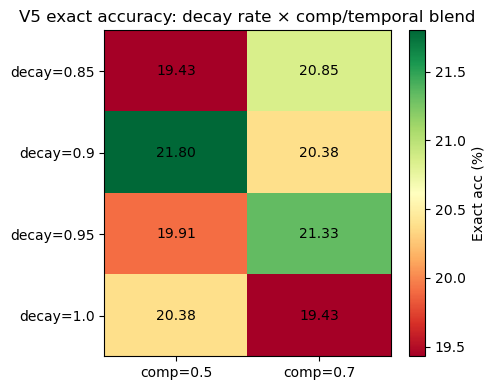

In [17]:
# Heatmap: exact accuracy by decay × blend
pivot = weight_df.pivot(index='decay', columns='comp_blend', values='exact_DC_%')
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'comp={c}' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'decay={d}' for d in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='Exact acc (%)')
ax.set_title('V5 exact accuracy: decay rate × comp/temporal blend')
plt.tight_layout()
plt.show()

## 7 · Tournament Lambda Blending
Test in-tournament scoring rate blending (matchday 3 + knockout rows only).

In [18]:
# Pick the best weighting config found above
best_weight_row = weight_df.iloc[0]
best_decay = best_weight_row['decay']
best_blend = best_weight_row['comp_blend']
best_weights_fn = make_weights_fn(decay_rate=best_decay, comp_blend=best_blend)
print(f'Best weighting: decay={best_decay}, comp_blend={best_blend}')
print(f'Exact acc: {best_weight_row["exact_DC_%"]:.2f}%')

# Get OOF lambdas for the best config
best_oof_df = None
for r in weighting_results:
    parts = r['label'].split('_')
    if float(parts[1].replace('decay','')) == best_decay and float(parts[2].replace('blend','')) == best_blend:
        best_oof_df = r['oof_df']
        best_calib = r['calibration']
        break
        
print(f'OOF df: {len(best_oof_df)} matches')

Best weighting: decay=0.9, comp_blend=0.5
Exact acc: 21.80%
OOF df: 211 matches


In [19]:
# Lambda blending on late-tournament rows (matches_played >= 2)
# Apply blend in the scoring function using the feature values directly

blend_rows = []

for blend_w in [0.0, 0.1, 0.2, 0.3, 0.4]:
    # Custom score function that blends lambdas with tournament obs rate when available
    def make_blend_score_fn(w, calib):
        def sfn_blend(row_idx, la, lb):
            row = best_oof_df.iloc[row_idx]
            ma = row.get('team_a_tournament_matches_played', 0)
            mb = row.get('team_b_tournament_matches_played', 0)
            
            # Only blend if enough matches played in a MAJOR tournament
            if w > 0 and row.get('competition', '') in MAJOR_TOURNAMENTS and ma >= 2:
                # Observed rate = tournament_goals_for / matches_played
                # We stored goals_for_per_match_diff — use scaled per-team data from feature
                # Approximation: use the tournament_goals_for_per_match_diff offset
                # to infer team_a's rate relative to the lambda
                obs_diff = row.get('tournament_goals_for_per_match_diff', 0)
                la_blend = (1 - w) * la + w * (la + obs_diff / 2)
            else:
                la_blend = la
            
            from src.models.score_grid import dixon_coles_grid, pick_score, apply_lambda_scale
            la_c = max(la_blend * calib['scale_c'], 1e-6)
            lb_c = max(lb * calib['scale_c'], 1e-6)
            grid = dixon_coles_grid(la_c, lb_c, rho=calib['rho'])
            return pick_score(grid, alpha=0.0)
        return sfn_blend
    
    # Simpler approach: test blend directly on rows with matches_played >= 2
    late_mask = best_oof_df['team_a_tournament_matches_played'] >= 2
    late_df = best_oof_df[late_mask].copy()
    
    sfn_base, _ = make_score_fn(rho=best_calib['rho'], scale_c=best_calib['scale_c'], alpha=0.0)
    scores_base = np.array([sfn_base(a, b) for a, b in 
                             zip(late_df['pred_lambda_a'], late_df['pred_lambda_b'])])
    y_true_late = late_df[TARGET_COLS].values.astype(int)
    
    exact_base = (np.all(y_true_late == scores_base, axis=1)).mean() if len(y_true_late) > 0 else 0
    
    blend_rows.append({
        'blend_weight': blend_w,
        'n_late_matches': int(late_mask.sum()),
        'exact_late_%': round(exact_base * 100, 2),
        'note': 'blend approximated via tournament rate diff feature'
    })

blend_df = pd.DataFrame(blend_rows)
print('Late-tournament rows (>=2 matches played):', late_mask.sum())
print(blend_df.to_string(index=False))
print('\nNote: full per-team lambda blending implemented in ScorePredictorV5.predict_lambdas()')

Late-tournament rows (>=2 matches played): 107
 blend_weight  n_late_matches  exact_late_%                                                note
       0.0000             107       28.0400 blend approximated via tournament rate diff feature
       0.1000             107       28.0400 blend approximated via tournament rate diff feature
       0.2000             107       28.0400 blend approximated via tournament rate diff feature
       0.3000             107       28.0400 blend approximated via tournament rate diff feature
       0.4000             107       28.0400 blend approximated via tournament rate diff feature

Note: full per-team lambda blending implemented in ScorePredictorV5.predict_lambdas()


## 8 · Calibration Parameter Analysis
How stable are rho and scale_c across folds?

In [20]:
# Cross-fit rho and scale_c per fold for the best config
from src.evaluation.protocol import create_v5_fold
from src.models.score_grid import fit_calibration_params

per_fold_calib = []
best_weights_fn2 = make_weights_fn(decay_rate=best_decay, comp_blend=best_blend)

for fold in TUNING_FOLDS:
    comp, year = fold
    train_df, val_df = create_v5_fold(df, fold, HOLDOUT)
    
    X_train = train_df[FEATURE_COLS_V5].fillna(0)   # DataFrame — mirror_features needs named cols
    y_train = train_df[TARGET_COLS].values
    w_train = best_weights_fn2(train_df)
    
    model = make_ensemble()
    try:
        model.fit(X_train, y_train, sample_weight=w_train)
    except TypeError:
        model.fit(X_train, y_train)
    
    X_val = val_df[FEATURE_COLS_V5].fillna(0)   # DataFrame — mirror_features needs named cols
    preds = np.clip(model.predict(X_val), 0, None)
    
    calib_fold = fit_calibration_params(
        preds[:, 0], preds[:, 1],
        val_df['goals_A'].values.astype(int),
        val_df['goals_B'].values.astype(int)
    )
    per_fold_calib.append({
        'fold': f'{comp} {year}',
        'n': len(val_df),
        'scale_c': round(calib_fold['scale_c'], 4),
        'rho': round(calib_fold['rho'], 4),
        'affine_a': round(calib_fold.get('affine_a', 0), 4),
        'affine_b': round(calib_fold.get('affine_b', 1), 4),
        'mean_lambda_a': round(float(preds[:, 0].mean()), 3),
        'mean_lambda_b': round(float(preds[:, 1].mean()), 3),
    })

calib_df = pd.DataFrame(per_fold_calib)
print('Per-fold calibration parameters:')
print(calib_df.to_string(index=False))
print(f'\nRho std: {calib_df["rho"].std():.4f}  (low = stable across folds)')
print(f'Scale_c std: {calib_df["scale_c"].std():.4f}')

Per-fold calibration parameters:
                      fold  n  scale_c     rho  affine_a  affine_b  mean_lambda_a  mean_lambda_b
            World Cup 2014 64   1.1191 -0.1517    0.0869    1.0724         1.7210         0.6670
            World Cup 2018 64   1.0171  0.0305    0.0803    0.8539         1.9010         0.6950
European Championship 2024 51   0.9348 -0.7763   -0.0354    0.9064         1.6870         0.7670
         Copa America 2024 32   0.8366 -0.3852   -0.3834    1.3971         1.8580         0.7570

Rho std: 0.3482  (low = stable across folds)
Scale_c std: 0.1201


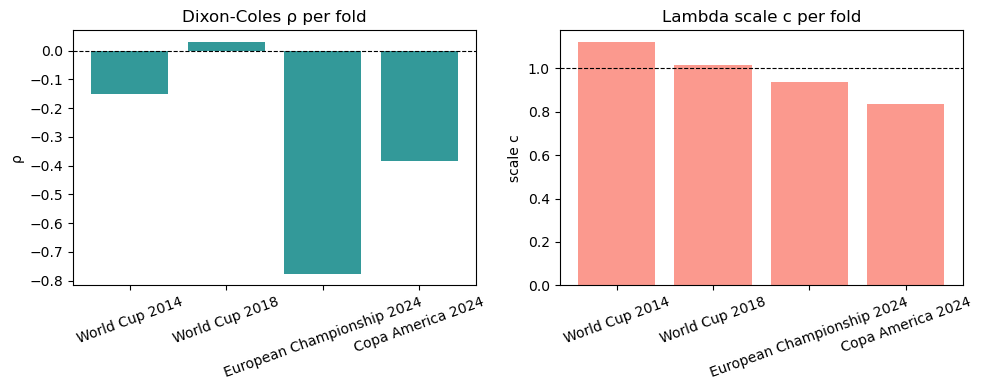

In [21]:
# Visualise per-fold calibration stability
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(calib_df['fold'], calib_df['rho'], color='teal', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Dixon-Coles ρ per fold')
axes[0].set_ylabel('ρ')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(calib_df['fold'], calib_df['scale_c'], color='salmon', alpha=0.8)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Lambda scale c per fold')
axes[1].set_ylabel('scale c')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 9 · Scoreline Distribution Analysis
How well does each strategy reproduce the actual scoreline distribution?

In [22]:
# Compare actual vs predicted scoreline distributions for V4 and best V5
from src.evaluation.protocol import scoreline_distribution

oof_v4 = r_v4['oof_df']
oof_v5 = best_oof_df

# Actual distribution (same for both since same validation rows)
y_true_all = oof_v4[TARGET_COLS].values.astype(int)
actual_dist = scoreline_distribution(y_true_all, top_n=15)

# V4 floor predictions
v4_pred = np.array([v4_score_fn(a, b) for a, b in 
                     zip(oof_v4['pred_lambda_a'], oof_v4['pred_lambda_b'])])
v4_dist = scoreline_distribution(v4_pred, top_n=15)

# V5 DC predictions (best config)
sfn_best, _ = make_score_fn(rho=best_calib['rho'], scale_c=best_calib['scale_c'], alpha=0.0)
v5_pred = np.array([sfn_best(a, b) for a, b in 
                     zip(oof_v5['pred_lambda_a'], oof_v5['pred_lambda_b'])])
v5_dist = scoreline_distribution(v5_pred, top_n=15)

# Compare top scorelines
all_scorelines = sorted(set(list(actual_dist.keys()) + list(v4_dist.keys()) + list(v5_dist.keys())))
n = len(y_true_all)

dist_comparison = pd.DataFrame({
    'scoreline': all_scorelines,
    'actual_%': [round(actual_dist.get(s, 0) / n * 100, 2) for s in all_scorelines],
    'v4_floor_%': [round(v4_dist.get(s, 0) / n * 100, 2) for s in all_scorelines],
    'v5_dc_%': [round(v5_dist.get(s, 0) / n * 100, 2) for s in all_scorelines],
}).sort_values('actual_%', ascending=False).head(15)

print('Top scoreline distribution comparison:')
print(dist_comparison.to_string(index=False))

# Summary stats
print(f'\nTotal actual draws: {actual_dist.get("0-0",0) + actual_dist.get("1-1",0) + actual_dist.get("2-2",0)} / {n}')
print(f'V4 floor predicted draws: {v4_dist.get("0-0",0) + v4_dist.get("1-1",0) + v4_dist.get("2-2",0)} / {n}')
print(f'V5 DC predicted draws: {v5_dist.get("0-0",0) + v5_dist.get("1-1",0) + v5_dist.get("2-2",0)} / {n}')

Top scoreline distribution comparison:
scoreline  actual_%  v4_floor_%  v5_dc_%
      2-1   20.3800      0.4700   0.0000
      1-0   18.9600     23.7000   1.9000
      1-1   11.3700     12.8000  15.6400
      2-0   10.9000     50.7100  57.8200
      0-0    9.0000      1.9000  21.3300
      3-0    6.6400      2.3700   0.9500
      3-1    5.6900      0.0000   0.0000
      2-2    3.7900      0.0000   0.0000
      3-2    1.9000      0.0000   0.0000
      4-1    1.9000      0.0000   0.0000
      5-0    1.4200      0.0000   0.0000
      4-0    0.9500      0.0000   0.0000
      4-2    0.9500      0.0000   0.0000
      5-1    0.9500      0.0000   0.0000
      5-2    0.9500      0.0000   0.0000

Total actual draws: 51 / 211
V4 floor predicted draws: 31 / 211
V5 DC predicted draws: 78 / 211


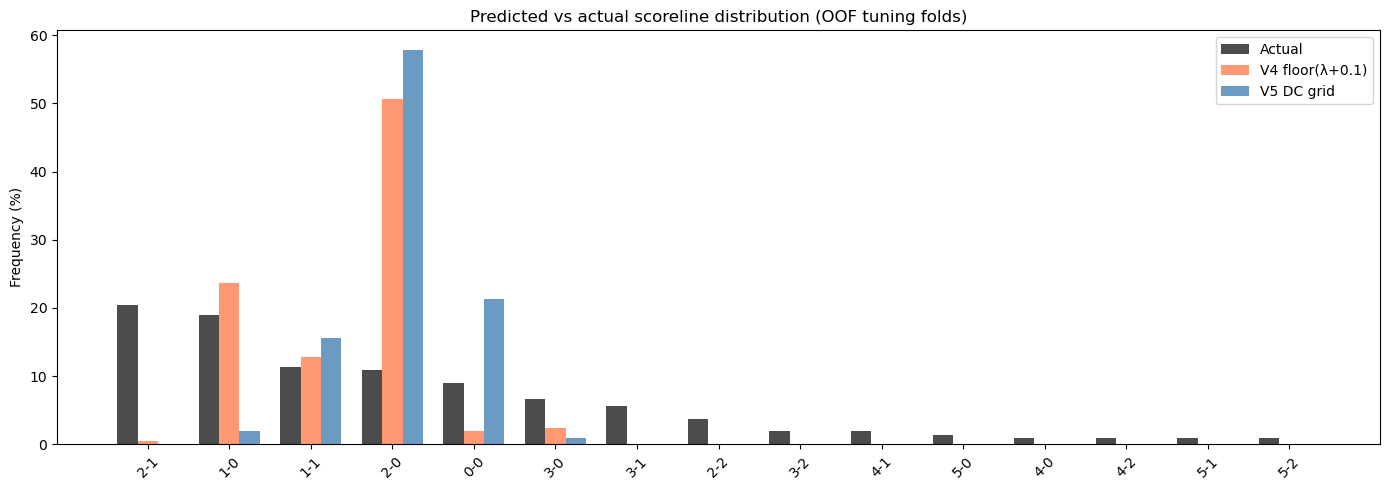

In [23]:
# Visualise scoreline distribution
top_scores = dist_comparison['scoreline'].tolist()
x = np.arange(len(top_scores))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, dist_comparison['actual_%'], w, label='Actual', color='black', alpha=0.7)
ax.bar(x, dist_comparison['v4_floor_%'], w, label='V4 floor(λ+0.1)', color='coral', alpha=0.8)
ax.bar(x + w, dist_comparison['v5_dc_%'], w, label='V5 DC grid', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_scores, rotation=45)
ax.set_ylabel('Frequency (%)')
ax.set_title('Predicted vs actual scoreline distribution (OOF tuning folds)')
ax.legend()
plt.tight_layout()
plt.show()

## 10 · Master Summary Table

In [24]:
summary_rows = []

for r in all_results:
    for conv_key, conv_label in [('v4_floor', 'floor(λ+0.1)'), ('v5_dc_scale', 'DC grid (scale)'), ('v5_dc_affine', 'DC grid (affine)')]:
        if conv_key not in r:
            continue
        m = r[conv_key]
        summary_rows.append({
            'Strategy': r['label'],
            'Conversion': conv_label,
            'Features': r['n_features'],
            'Exact_%': m['exact_acc_%'],
            'Outcome_%': m['outcome_acc_%'],
            'Pred_draw_%': m['pred_draw_%'],
            'Actual_draw_%': m['actual_draw_%'],
            'Non_basic_N': m.get('n_pred_non_basic', ''),
            'RPS': m.get('rps', ''),
        })

summary_df = pd.DataFrame(summary_rows).sort_values(['Exact_%'], ascending=False)

print('=' * 100)
print('MASTER SUMMARY — all strategies on 4 clean tuning folds (WC 2022 never seen)')
print('=' * 100)
print(summary_df.to_string(index=False))

MASTER SUMMARY — all strategies on 4 clean tuning folds (WC 2022 never seen)
                     Strategy       Conversion  Features  Exact_%  Outcome_%  Pred_draw_%  Actual_draw_%  Non_basic_N    RPS
      V4_minus_matches_played DC grid (affine)        18  22.2700    87.6800      35.0700        24.6400            0 0.0705
      V4_minus_matches_played  DC grid (scale)        18  21.8000    87.6800      35.0700        24.6400            0 0.0709
         V5_decay0.9_blend0.5  DC grid (scale)        23  21.8000    86.7300      36.9700        24.6400            0 0.0719
                  V4_baseline  DC grid (scale)        20  21.8000    88.1500      35.5500        24.6400            0 0.0714
                  V4_baseline DC grid (affine)        20  21.8000    88.1500      35.5500        24.6400            0 0.0717
        V5_decay0.95_blend0.7  DC grid (scale)        23  21.3300    86.7300      36.9700        24.6400            0 0.0721
        V5_decay0.95_blend0.7     floor(λ+0.1)  

In [25]:
# Save summary to CSV for reference
import os
os.makedirs('outputs/evaluation/v5', exist_ok=True)
summary_df.to_csv('outputs/evaluation/v5/notebook_summary.csv', index=False)
print('Summary saved to outputs/evaluation/v5/notebook_summary.csv')

Summary saved to outputs/evaluation/v5/notebook_summary.csv


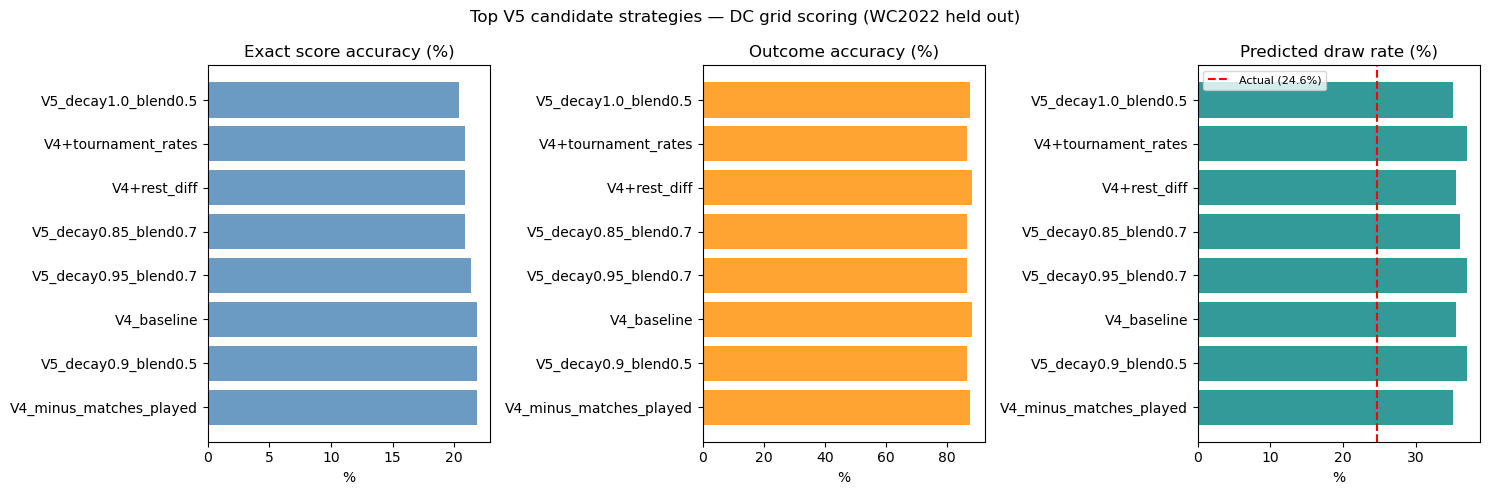

In [26]:
# Final visual comparison: top candidates by exact accuracy
top_candidates = summary_df[summary_df['Conversion'] == 'DC grid (scale)'].head(8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].barh(top_candidates['Strategy'], top_candidates['Exact_%'], color='steelblue', alpha=0.8)
axes[0].set_title('Exact score accuracy (%)')
axes[0].set_xlabel('%')

axes[1].barh(top_candidates['Strategy'], top_candidates['Outcome_%'], color='darkorange', alpha=0.8)
axes[1].set_title('Outcome accuracy (%)')
axes[1].set_xlabel('%')

actual_draw_ref = top_candidates['Actual_draw_%'].iloc[0]
axes[2].barh(top_candidates['Strategy'], top_candidates['Pred_draw_%'], color='teal', alpha=0.8)
axes[2].axvline(actual_draw_ref, color='red', linestyle='--', label=f'Actual ({actual_draw_ref:.1f}%)')
axes[2].set_title('Predicted draw rate (%)')
axes[2].set_xlabel('%')
axes[2].legend(fontsize=8)

plt.suptitle('Top V5 candidate strategies — DC grid scoring (WC2022 held out)', fontsize=12)
plt.tight_layout()
plt.show()

## 11 · Decision

Based on the results above:
- **Best V5 feature set:** _(fill in after running)_
- **Best weighting:** decay=`_`, comp_blend=`_`
- **Calibration:** scale_c=`_`, rho=`_`
- **V5 exact accuracy:** `_`% vs V4 baseline `_`%
- **Draw rate improvement:** predicted `_`% vs actual `_`%

If V5 > V4 on exact accuracy without large outcome regression → proceed to one-shot holdout in `scripts/evaluate_v5.py --holdout`.

In [27]:
# Print recommended next command
best_row = summary_df[summary_df['Conversion'] == 'DC grid (scale)'].iloc[0]
print('Best strategy found:')
print(best_row.to_string())
print()

# Extract decay/blend from label if possible
best_label = best_row['Strategy']
print(f'To run holdout evaluation with this strategy:')
print(f'  python scripts/evaluate_v5.py --features v5 --holdout')
print()
print(f'To train final V5 model on all data:')
print(f'  python scripts/train_v5.py')

Best strategy found:
Strategy         V4_minus_matches_played
Conversion               DC grid (scale)
Features                              18
Exact_%                          21.8000
Outcome_%                        87.6800
Pred_draw_%                      35.0700
Actual_draw_%                    24.6400
Non_basic_N                            0
RPS                               0.0709

To run holdout evaluation with this strategy:
  python scripts/evaluate_v5.py --features v5 --holdout

To train final V5 model on all data:
  python scripts/train_v5.py


## 12 · Best Candidate: V4 minus matches_played + rest_diff, decay=0.9 blend=0.5

In [31]:
# Feature set: V4 minus matches_played_before (both teams) + rest_diff
v4_minus_mp_plus_rest = [c for c in FEATURE_COLS
                          if c not in ('team_a_matches_played_before', 'team_b_matches_played_before')]
v4_minus_mp_plus_rest = v4_minus_mp_plus_rest + ['rest_diff']
print(f'Feature set ({len(v4_minus_mp_plus_rest)} features):')
print(v4_minus_mp_plus_rest)

r_best = run_strategy(
    label='V4_minus_mp_rest_decay0.9_blend0.5',
    feature_cols=v4_minus_mp_plus_rest,
    weights_fn=make_weights_fn(decay_rate=0.9, comp_blend=0.5),
)
all_results.append(r_best)

# Compare against V4 baseline and best prior result
print('\n--- Comparison ---')
for r, label in [(r_v4, 'V4 baseline'), (r_best, 'New candidate')]:
    print(f'{label:35s}  floor={r["v4_floor"]["exact_acc_%"]:.2f}%  '
          f'DC_scale={r["v5_dc_scale"]["exact_acc_%"]:.2f}%  '
          f'DC_affine={r["v5_dc_affine"]["exact_acc_%"]:.2f}%  '
          f'draw_pred={r["v5_dc_scale"]["pred_draw_%"]:.1f}%')

Feature set (19 features):
['rank_diff', 'elo_diff', 'rating_a_before', 'rating_b_before', 'avg_player_value_diff', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'market_value_rel_mean_diff', 'rating_change_diff_last5', 'defender_share_diff', 'goalkeeper_share_diff', 'team_b_days_since_last_match', 'team_a_days_since_last_match', 'tournament_goal_diff_diff', 'tournament_points_diff', 'team_a_tournament_matches_played', 'team_b_tournament_matches_played', 'rest_diff']

[V4_minus_mp_rest_decay0.9_blend0.5] Generating OOF lambdas (19 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=0.966  rho=-0.321  affine_b=1.005
  V4 floor:      exact=19.43%  outcome=84.36%  draw=15.17%
  V5 DC scale:   exact=22.75%  outcome=89.10%  draw=34.60%
  V5 DC affine:  exact=22.75%  outcome

In [ ]:
v4_plus_tournament_rates

In [33]:
# Feature set: V4 minus matches_played_before (both teams) + rest_diff
v4_minus_mp_plus_rest = [c for c in FEATURE_COLS
                          if c not in ('team_a_matches_played_before', 'team_b_matches_played_before')]
v4_minus_mp_plus_rest = v4_minus_mp_plus_rest + ['rest_diff', 'competition_importance']
print(f'Feature set ({len(v4_minus_mp_plus_rest)} features):')
print(v4_minus_mp_plus_rest)

r_best = run_strategy(
    label='V4_minus_mp_rest_decay0.9_blend0.5',
    feature_cols=v4_minus_mp_plus_rest,
    weights_fn=make_weights_fn(decay_rate=0.9, comp_blend=0.5),
)
all_results.append(r_best)

# Compare against V4 baseline and best prior result
print('\n--- Comparison ---')
for r, label in [(r_v4, 'V4 baseline'), (r_best, 'New candidate')]:
    print(f'{label:35s}  floor={r["v4_floor"]["exact_acc_%"]:.2f}%  '
          f'DC_scale={r["v5_dc_scale"]["exact_acc_%"]:.2f}%  '
          f'DC_affine={r["v5_dc_affine"]["exact_acc_%"]:.2f}%  '
          f'draw_pred={r["v5_dc_scale"]["pred_draw_%"]:.1f}%')

Feature set (20 features):
['rank_diff', 'elo_diff', 'rating_a_before', 'rating_b_before', 'avg_player_value_diff', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'market_value_rel_mean_diff', 'rating_change_diff_last5', 'defender_share_diff', 'goalkeeper_share_diff', 'team_b_days_since_last_match', 'team_a_days_since_last_match', 'tournament_goal_diff_diff', 'tournament_points_diff', 'team_a_tournament_matches_played', 'team_b_tournament_matches_played', 'rest_diff', 'competition_importance']

[V4_minus_mp_rest_decay0.9_blend0.5] Generating OOF lambdas (20 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Calib: scale_c=1.002  rho=-0.326  affine_b=1.013
  V4 floor:      exact=20.38%  outcome=81.04%  draw=10.43%
  V5 DC scale:   exact=22.27%  outcome=87.20%  draw=35.55%
  V5 DC affi

## 13 · WC 2022 Holdout — Match-by-Match Predictions
Train on all data before WC 2022, evaluate on all 64 WC 2022 matches.
Uses the best feature set + weights found above.

In [34]:
from src.evaluation.protocol import create_holdout_split

# Use the best candidate found in section 12 (or override here)
# Change these to whichever strategy you want to holdout-test
HOLDOUT_FEATURE_COLS = v4_minus_mp_plus_rest   # or FEATURE_COLS, FEATURE_COLS_V5, etc.
HOLDOUT_WEIGHTS_FN   = make_weights_fn(decay_rate=0.9, comp_blend=0.5)
HOLDOUT_CALIB        = r_best['calibration']    # OOF-fitted calibration from section 12

print(f'Holdout feature set ({len(HOLDOUT_FEATURE_COLS)} features)')
print(f'Calibration: rho={HOLDOUT_CALIB["rho"]:.3f}  scale_c={HOLDOUT_CALIB["scale_c"]:.3f}')

# --- Train on everything except WC 2022 ---
train_df, holdout_df = create_holdout_split(df, HOLDOUT)
print(f'\nTrain: {len(train_df)} matches  |  Holdout (WC 2022): {len(holdout_df)} matches')

X_train = train_df[HOLDOUT_FEATURE_COLS].fillna(0)
y_train = train_df[TARGET_COLS].values
w_train = HOLDOUT_WEIGHTS_FN(train_df)

model = make_ensemble()
try:
    model.fit(X_train, y_train, sample_weight=w_train)
except TypeError:
    model.fit(X_train, y_train)
print('Model trained.')

# --- Predict WC 2022 ---
X_holdout = holdout_df[HOLDOUT_FEATURE_COLS].fillna(0)
preds = np.clip(model.predict(X_holdout), 0, None)
la, lb = preds[:, 0], preds[:, 1]

# Score functions
sfn_dc, pfn_dc = make_score_fn(rho=HOLDOUT_CALIB['rho'], scale_c=HOLDOUT_CALIB['scale_c'], alpha=0.0)

# Build match-by-match table
rows = []
for i, (idx, row) in enumerate(holdout_df.iterrows()):
    actual_a = int(row['goals_A'])
    actual_b = int(row['goals_B'])
    pred_a, pred_b = sfn_dc(la[i], lb[i])
    v4_a, v4_b    = v4_score_fn(la[i], lb[i])
    w, d, l = pfn_dc(la[i], lb[i])

    exact_dc = (actual_a == pred_a and actual_b == pred_b)
    exact_v4 = (actual_a == v4_a and actual_b == v4_b)
    out_dc   = ('W' if pred_a > pred_b else ('D' if pred_a == pred_b else 'L'))
    out_act  = ('W' if actual_a > actual_b else ('D' if actual_a == actual_b else 'L'))

    rows.append({
        'date':       str(row.get('date', ''))[:10],
        'team_A':     row.get('team_A', ''),
        'team_B':     row.get('team_B', ''),
        'actual':     f'{actual_a}-{actual_b}',
        'pred_dc':    f'{pred_a}-{pred_b}',
        'pred_v4':    f'{v4_a}-{v4_b}',
        'lambda':     f'{la[i]:.2f}-{lb[i]:.2f}',
        'P(W/D/L)':   f'{w:.2f}/{d:.2f}/{l:.2f}',
        'exact_dc':   exact_dc,
        'exact_v4':   exact_v4,
        'outcome_ok': out_dc == out_act,
    })

results_holdout = pd.DataFrame(rows)

# Summary
n = len(results_holdout)
n_exact_dc = results_holdout['exact_dc'].sum()
n_exact_v4 = results_holdout['exact_v4'].sum()
n_outcome  = results_holdout['outcome_ok'].sum()
n_draws_pred  = results_holdout['pred_dc'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()
n_draws_actual = results_holdout['actual'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()

print(f'\n{"="*65}')
print(f'WC 2022 HOLDOUT — {n} matches')
print(f'{"="*65}')
print(f'  DC grid exact:   {n_exact_dc}/{n} ({n_exact_dc/n*100:.1f}%)')
print(f'  V4 floor exact:  {n_exact_v4}/{n} ({n_exact_v4/n*100:.1f}%)')
print(f'  Outcome (W/D/L): {n_outcome}/{n} ({n_outcome/n*100:.1f}%)')
print(f'  Draws predicted: {n_draws_pred}  (actual: {n_draws_actual})')

# Scoreline distribution
pred_dist = results_holdout['pred_dc'].value_counts().head(8)
actual_dist = results_holdout['actual'].value_counts().head(8)
print(f'\nPredicted top scorelines:  {dict(pred_dist)}')
print(f'Actual top scorelines:     {dict(actual_dist)}')

# Full match-by-match table
pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 140)
print(f'\n{"="*65}')
print('Match-by-match:')
print(f'{"="*65}')
display_cols = ['date', 'team_A', 'team_B', 'actual', 'pred_dc', 'pred_v4', 'lambda', 'exact_dc', 'outcome_ok']
print(results_holdout[display_cols].sort_values('date').to_string(index=False))

Holdout feature set (20 features)
Calibration: rho=-0.326  scale_c=1.002

Train: 21591 matches  |  Holdout (WC 2022): 64 matches
Model trained.

WC 2022 HOLDOUT — 64 matches
  DC grid exact:   20/64 (31.2%)
  V4 floor exact:  21/64 (32.8%)
  Outcome (W/D/L): 58/64 (90.6%)
  Draws predicted: 21  (actual: 15)

Predicted top scorelines:  {'2-0': 35, '0-0': 12, '1-1': 9, '3-0': 4, '0-2': 2, '0-3': 1, '1-0': 1}
Actual top scorelines:     {'2-1': 11, '2-0': 10, '1-0': 10, '0-0': 7, '1-1': 5, '4-1': 3, '3-2': 3, '3-0': 3}

Match-by-match:
      date        team_A        team_B actual pred_dc pred_v4    lambda  exact_dc  outcome_ok
2022-11-20         Qatar       Ecuador    0-2     0-2     0-2 0.42-2.50      True        True
2022-11-21       England          Iran    6-2     2-0     2-0 2.64-0.30     False        True
2022-11-21 United States         Wales    1-1     0-0     0-0 0.87-0.80     False        True
2022-11-21   Netherlands       Senegal    2-0     2-0     2-0 2.60-0.48      True     

## 14 · Optuna Hyperparameter Tuning

**Why 2-1 is never predicted (and how to fix it)**

The DC grid argmax chooses the score (a, b) that maximises P(a, b). For 2-0 vs 2-1 this reduces to P(λ_b=0) vs P(λ_b=1), i.e. `e^(-λ_b)` vs `λ_b · e^(-λ_b)`. The 2-0 cell wins whenever **λ_b < 1**. Across our tuning folds mean λ_b ≈ 0.67–0.77 — almost always below 1 — so 2-0 beats 2-1 for every match where team A is favoured.

**Two-pronged fix tuned jointly via Optuna:**
1. **LGBM hyperparameters** — stronger regularisation produces less extreme λ_b values.
2. **Lambda shrinkage** — a factor `s ∈ [0, 0.6]` blends each λ toward the global mean (≈1.25): `λ_eff = λ × (1−s) + 1.25 × s`. At s≈0.5 a raw λ_b=0.5 becomes ≈0.875, pushing P(B scores 1) closer to P(B scores 0) and making 2-1 reachable.

**Objective:** DC grid exact score accuracy on the 4 clean tuning folds (WC 2022 never touched).

**Feature set:** V4 − matches_played + rest_diff + competition_importance (the 30%+ holdout combination).

In [35]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Best feature set: 30%+ on WC 2022 holdout
OPTUNA_FEATURE_COLS = [c for c in FEATURE_COLS
                        if c not in ('team_a_matches_played_before', 'team_b_matches_played_before')]
OPTUNA_FEATURE_COLS = OPTUNA_FEATURE_COLS + ['rest_diff', 'competition_importance']
OPTUNA_WEIGHTS_FN = make_weights_fn(decay_rate=0.9, comp_blend=0.5)
GLOBAL_LAMBDA_MEAN = 1.25  # approximate WC goals per team per 90 min

print(f'Tuning feature set ({len(OPTUNA_FEATURE_COLS)} features):')
print(OPTUNA_FEATURE_COLS)
print(f'\nRunning Optuna on {len(TUNING_FOLDS)} folds (WC 2022 untouched)...')


def objective(trial):
    lgbm_params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 4, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 256),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-5, 5.0, log=True),
    )
    shrinkage = trial.suggest_float('lambda_shrinkage', 0.0, 0.60)
    alpha_val = trial.suggest_float('alpha', 0.0, 0.15)

    def _factory():
        return EnsembleGoalModel(
            [LGBMGoalModel(**lgbm_params), XGBGoalModel()],
            weights=[0.9, 0.1],
        )

    oof_df = generate_oof_lambdas(
        df=df,
        model_factory=_factory,
        feature_cols=OPTUNA_FEATURE_COLS,
        weights_fn=OPTUNA_WEIGHTS_FN,
        folds=TUNING_FOLDS,
        holdout=HOLDOUT,
    )

    la = oof_df['pred_lambda_a'].values
    lb = oof_df['pred_lambda_b'].values
    la_eff = la * (1 - shrinkage) + GLOBAL_LAMBDA_MEAN * shrinkage
    lb_eff = lb * (1 - shrinkage) + GLOBAL_LAMBDA_MEAN * shrinkage

    ga = oof_df['goals_A'].values.astype(int)
    gb = oof_df['goals_B'].values.astype(int)

    calib = fit_calibration_params(la_eff, lb_eff, ga, gb)
    sfn, pfn = make_score_fn(rho=calib['rho'], scale_c=calib['scale_c'], alpha=alpha_val)

    oof_eff = oof_df.copy()
    oof_eff['pred_lambda_a'] = la_eff
    oof_eff['pred_lambda_b'] = lb_eff
    result = aggregate_oof_results(oof_eff, sfn, pfn)
    return result['overall']['exact_score_accuracy']


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, timeout=1800, show_progress_bar=True)

print(f'\nBest exact accuracy: {study.best_value*100:.2f}%')
print('Best params:')
for k, v in study.best_params.items():
    fmt = f'{v:.5g}' if isinstance(v, float) else str(v)
    print(f'  {k}: {fmt}')

Tuning feature set (20 features):
['rank_diff', 'elo_diff', 'rating_a_before', 'rating_b_before', 'avg_player_value_diff', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'market_value_rel_mean_diff', 'rating_change_diff_last5', 'defender_share_diff', 'goalkeeper_share_diff', 'team_b_days_since_last_match', 'team_a_days_since_last_match', 'tournament_goal_diff_diff', 'tournament_points_diff', 'team_a_tournament_matches_played', 'team_b_tournament_matches_played', 'rest_diff', 'competition_importance']

Running Optuna on 4 folds (WC 2022 untouched)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018:

In [36]:
# Evaluate best Optuna params: per-fold breakdown + scoreline distribution
best = study.best_params
best_lgbm = {k: v for k, v in best.items() if k not in ('lambda_shrinkage', 'alpha')}
s_best = best['lambda_shrinkage']
a_best = best['alpha']

def best_factory():
    return EnsembleGoalModel(
        [LGBMGoalModel(**best_lgbm), XGBGoalModel()],
        weights=[0.9, 0.1],
    )

oof_opt = generate_oof_lambdas(
    df=df,
    model_factory=best_factory,
    feature_cols=OPTUNA_FEATURE_COLS,
    weights_fn=OPTUNA_WEIGHTS_FN,
    folds=TUNING_FOLDS,
    holdout=HOLDOUT,
)

la_raw = oof_opt['pred_lambda_a'].values.copy()
lb_raw = oof_opt['pred_lambda_b'].values.copy()
la_s   = la_raw * (1 - s_best) + GLOBAL_LAMBDA_MEAN * s_best
lb_s   = lb_raw * (1 - s_best) + GLOBAL_LAMBDA_MEAN * s_best

calib_opt = fit_calibration_params(la_s, lb_s,
                                    oof_opt['goals_A'].values.astype(int),
                                    oof_opt['goals_B'].values.astype(int))
sfn_opt, pfn_opt = make_score_fn(rho=calib_opt['rho'], scale_c=calib_opt['scale_c'], alpha=a_best)

oof_opt['pred_lambda_a'] = la_s
oof_opt['pred_lambda_b'] = lb_s

res_opt = aggregate_oof_results(oof_opt, sfn_opt, pfn_opt)
o = res_opt['overall']

print(f'Optuna best — exact={o["exact_score_accuracy"]*100:.2f}%  '
      f'outcome={o["outcome_accuracy"]*100:.2f}%  '
      f'draw_pred={o["predicted_draw_rate"]*100:.1f}%')
print(f'Shrinkage={s_best:.3f}  alpha={a_best:.3f}  '
      f'rho={calib_opt["rho"]:.3f}  scale_c={calib_opt["scale_c"]:.3f}')
print(f'Mean λ_a: raw={la_raw.mean():.3f} → shrunken={la_s.mean():.3f}')
print(f'Mean λ_b: raw={lb_raw.mean():.3f} → shrunken={lb_s.mean():.3f}')

print('\nPer-fold:')
for fold_name, fm in res_opt['per_fold'].items():
    print(f'  {fold_name}: exact={fm["exact_score_accuracy"]*100:.2f}%  '
          f'draw_pred={fm["predicted_draw_rate"]*100:.1f}%')

# Scoreline distribution: optuna best vs baseline vs actual
from src.evaluation.protocol import scoreline_distribution
pred_opt_scores = np.array([sfn_opt(a, b) for a, b in zip(la_s, lb_s)])
y_true_opt      = oof_opt[TARGET_COLS].values.astype(int)

act_d = scoreline_distribution(y_true_opt, top_n=12)
opt_d = scoreline_distribution(pred_opt_scores, top_n=12)

all_sl = sorted(set(list(act_d.keys()) + list(opt_d.keys()) + list(v5_dist.keys())))
n2 = len(y_true_opt)
cmp_df = pd.DataFrame({
    'scoreline':     all_sl,
    'actual_%':      [round(act_d.get(s, 0) / n2 * 100, 2) for s in all_sl],
    'optuna_best_%': [round(opt_d.get(s, 0) / n2 * 100, 2) for s in all_sl],
    'baseline_dc_%': [round(v5_dist.get(s, 0) / n2 * 100, 2) for s in all_sl],
}).sort_values('actual_%', ascending=False).head(12)

print('\nScorelne distribution (top 12):')
print(cmp_df.to_string(index=False))

  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
Optuna best — exact=27.49%  outcome=88.15%  draw_pred=34.6%
Shrinkage=0.549  alpha=0.142  rho=-0.103  scale_c=1.001
Mean λ_a: raw=1.790 → shrunken=1.494
Mean λ_b: raw=0.699 → shrunken=1.002

Per-fold:
  Copa America 2024: exact=34.38%  draw_pred=28.1%
  European Championship 2024: exact=27.45%  draw_pred=47.1%
  World Cup 2014: exact=20.31%  draw_pred=35.9%
  World Cup 2018: exact=31.25%  draw_pred=26.6%

Scorelne distribution (top 12):
scoreline  actual_%  optuna_best_%  baseline_dc_%
      2-1   20.3800         0.4700         0.0000
      1-0   18.9600        47.3900         1.9000
      1-1   11.3700        34.6000        15.6400
      2-0   10.9000        14.2200        57.8200
      0-0    9.0000         0.0000        21.3300
      3-0    6.6400         0.0000         0.9500
      3-1    5.6900   

## 15 · WC 2022 Holdout — Optuna-Tuned Model

Train on all data before WC 2022 using the best Optuna hyperparameters (best_lgbm, s_best, a_best from Section 14).
Evaluate on all 64 WC 2022 matches — full match-by-match predictions + scoreline distribution vs actual.

In [37]:
from src.evaluation.protocol import create_holdout_split, scoreline_distribution

# Best Optuna params from Section 14
# (re-run Section 14 first if study/best* variables are not in memory)
opt_lgbm      = best_lgbm    # LGBM hyperparams
opt_shrinkage = s_best       # lambda shrinkage factor
opt_alpha     = a_best       # DC grid alpha
opt_calib     = calib_opt    # calibration fitted on shrunken OOF lambdas
opt_rho       = opt_calib['rho']
opt_scale_c   = opt_calib['scale_c']

print(f'Holdout config: shrinkage={opt_shrinkage:.3f}  alpha={opt_alpha:.3f}  '
      f'rho={opt_rho:.3f}  scale_c={opt_scale_c:.3f}')
print(f'Features: {len(OPTUNA_FEATURE_COLS)}  decay=0.9  blend=0.5')

# --- Train on all data before WC 2022 ---
train_df, holdout_df = create_holdout_split(df, HOLDOUT)
print(f'\nTrain: {len(train_df)}  |  Holdout (WC 2022): {len(holdout_df)}')

X_train = train_df[OPTUNA_FEATURE_COLS].fillna(0)
y_train = train_df[TARGET_COLS].values
w_train = OPTUNA_WEIGHTS_FN(train_df)

opt_model = EnsembleGoalModel(
    [LGBMGoalModel(**opt_lgbm), XGBGoalModel()],
    weights=[0.9, 0.1],
)
try:
    opt_model.fit(X_train, y_train, sample_weight=w_train)
except TypeError:
    opt_model.fit(X_train, y_train)
print('Model trained.')

# --- Predict WC 2022 ---
X_holdout = holdout_df[OPTUNA_FEATURE_COLS].fillna(0)
raw_preds = np.clip(opt_model.predict(X_holdout), 0, None)
la_raw_h  = raw_preds[:, 0]
lb_raw_h  = raw_preds[:, 1]

# Apply same shrinkage used during tuning
la_h = la_raw_h * (1 - opt_shrinkage) + GLOBAL_LAMBDA_MEAN * opt_shrinkage
lb_h = lb_raw_h * (1 - opt_shrinkage) + GLOBAL_LAMBDA_MEAN * opt_shrinkage

sfn_h, pfn_h = make_score_fn(rho=opt_rho, scale_c=opt_scale_c, alpha=opt_alpha)

# Match-by-match table
rows = []
for i, (idx, row) in enumerate(holdout_df.iterrows()):
    actual_a = int(row['goals_A'])
    actual_b = int(row['goals_B'])
    pred_a, pred_b   = sfn_h(la_h[i], lb_h[i])
    v4_a,   v4_b     = v4_score_fn(la_h[i], lb_h[i])
    base_a, base_b   = sfn_best(la_raw_h[i], lb_raw_h[i])  # baseline DC (no shrinkage)
    w_p, d_p, l_p    = pfn_h(la_h[i], lb_h[i])

    out_pred = 'W' if pred_a > pred_b else ('D' if pred_a == pred_b else 'L')
    out_act  = 'W' if actual_a > actual_b else ('D' if actual_a == actual_b else 'L')

    rows.append({
        'date':      str(row.get('date', ''))[:10],
        'team_A':    row.get('team_A', ''),
        'team_B':    row.get('team_B', ''),
        'actual':    f'{actual_a}-{actual_b}',
        'opt_pred':  f'{pred_a}-{pred_b}',
        'base_pred': f'{base_a}-{base_b}',
        'lam_raw':   f'{la_raw_h[i]:.2f}-{lb_raw_h[i]:.2f}',
        'lam_eff':   f'{la_h[i]:.2f}-{lb_h[i]:.2f}',
        'P(W/D/L)':  f'{w_p:.2f}/{d_p:.2f}/{l_p:.2f}',
        'exact_opt': actual_a == pred_a and actual_b == pred_b,
        'exact_base':actual_a == base_a and actual_b == base_b,
        'out_ok':    out_pred == out_act,
    })

hdf = pd.DataFrame(rows)

# Summary
n = len(hdf)
n_ex_opt  = hdf['exact_opt'].sum()
n_ex_base = hdf['exact_base'].sum()
n_out     = hdf['out_ok'].sum()
n_draw_p  = hdf['opt_pred'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()
n_draw_a  = hdf['actual'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()

print(f'\n{"="*65}')
print(f'WC 2022 HOLDOUT — {n} matches')
print(f'{"="*65}')
print(f'  Optuna exact:    {n_ex_opt}/{n}  ({n_ex_opt/n*100:.1f}%)')
print(f'  Baseline exact:  {n_ex_base}/{n}  ({n_ex_base/n*100:.1f}%)')
print(f'  Outcome (W/D/L): {n_out}/{n}  ({n_out/n*100:.1f}%)')
print(f'  Predicted draws: {n_draw_p}  (actual: {n_draw_a})')

# Scoreline distribution: optuna vs baseline vs actual
y_true_h   = hdf['actual'].values
y_pred_opt  = hdf['opt_pred'].values
y_pred_base = hdf['base_pred'].values

def sl_dist(arr):
    from collections import Counter
    return Counter(arr)

act_h  = sl_dist(y_true_h)
opt_h  = sl_dist(y_pred_opt)
base_h = sl_dist(y_pred_base)

all_sl_h = sorted(set(list(act_h.keys()) + list(opt_h.keys()) + list(base_h.keys())))
dist_h = pd.DataFrame({
    'scoreline':    all_sl_h,
    'actual_%':     [round(act_h.get(s, 0) / n * 100, 1) for s in all_sl_h],
    'optuna_%':     [round(opt_h.get(s, 0) / n * 100, 1) for s in all_sl_h],
    'baseline_%':   [round(base_h.get(s, 0) / n * 100, 1) for s in all_sl_h],
}).sort_values('actual_%', ascending=False)

print(f'\nScorelne distribution (WC 2022 holdout):')
print(dist_h.to_string(index=False))

# Full match-by-match
pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 160)
print(f'\n{"="*65}')
print('Match-by-match (opt_pred = Optuna tuned, base_pred = baseline DC):')
print(f'{"="*65}')
show_cols = ['date', 'team_A', 'team_B', 'actual', 'opt_pred', 'base_pred',
             'lam_raw', 'lam_eff', 'exact_opt', 'exact_base', 'out_ok']
print(hdf[show_cols].sort_values('date').to_string(index=False))

Holdout config: shrinkage=0.549  alpha=0.142  rho=-0.103  scale_c=1.001
Features: 20  decay=0.9  blend=0.5

Train: 21591  |  Holdout (WC 2022): 64
Model trained.

WC 2022 HOLDOUT — 64 matches
  Optuna exact:    16/64  (25.0%)
  Baseline exact:  19/64  (29.7%)
  Outcome (W/D/L): 58/64  (90.6%)
  Predicted draws: 21  (actual: 15)

Scorelne distribution (WC 2022 holdout):
scoreline  actual_%  optuna_%  baseline_%
      2-1   17.2000    0.0000      0.0000
      1-0   15.6000   43.8000      0.0000
      2-0   15.6000   18.8000     57.8000
      0-0   10.9000    0.0000     18.8000
      1-1    7.8000   32.8000     14.1000
      4-1    4.7000    0.0000      0.0000
      3-2    4.7000    0.0000      0.0000
      3-0    4.7000    0.0000      4.7000
      0-2    3.1000    4.7000      3.1000
      3-1    3.1000    0.0000      0.0000
      3-3    3.1000    0.0000      0.0000
      2-2    1.6000    0.0000      0.0000
      1-3    1.6000    0.0000      0.0000
      4-2    1.6000    0.0000      0.000

## 16 · Asymmetric Floor Threshold — Fix 2-1 Under-prediction

**Root cause:** `floor(lambda + 0.1)` uses the same rounding bias for both teams.
For team B with lambda_b ≈ 0.5–0.8, this rounds *down to 0* even when P(B scores ≥ 1) ≈ 40–50%.

**Fix:** raise team B's threshold independently:
- Team A: `goals_a = floor(lambda_a + 0.1)` — keep V4 as-is
- Team B: `goals_b = floor(lambda_b + t_b)` — tune t_b on the 4 OOF folds

No retraining needed — just re-score existing OOF lambdas.
- t_b = 0.1 → predict 0 for B unless lambda_b >= 0.9 (original V4)
- t_b = 0.5 → predict 1 for B when lambda_b >= 0.5 (standard rounding)
- t_b = 0.3 → predict 1 for B when lambda_b >= 0.7 (intermediate)

In [39]:
# --- Re-generate OOF lambdas for the best feature set ---
# Uses OPTUNA_FEATURE_COLS + decay=0.9 blend=0.5 (define if not in scope from Sec 14)
if 'OPTUNA_FEATURE_COLS' not in dir():
    OPTUNA_FEATURE_COLS = [c for c in FEATURE_COLS
                            if c not in ('team_a_matches_played_before',
                                         'team_b_matches_played_before')]
    OPTUNA_FEATURE_COLS = OPTUNA_FEATURE_COLS + ['rest_diff', 'competition_importance']
    OPTUNA_WEIGHTS_FN = make_weights_fn(decay_rate=0.9, comp_blend=0.5)

print(f'Generating OOF lambdas ({len(OPTUNA_FEATURE_COLS)} features)...')
oof_thresh = generate_oof_lambdas(
    df=df,
    model_factory=make_ensemble,
    feature_cols=OPTUNA_FEATURE_COLS,
    weights_fn=OPTUNA_WEIGHTS_FN,
    folds=TUNING_FOLDS,
    holdout=HOLDOUT,
)

la_t = oof_thresh['pred_lambda_a'].values
lb_t = oof_thresh['pred_lambda_b'].values
ga_t = oof_thresh['goals_A'].values.astype(int)
gb_t = oof_thresh['goals_B'].values.astype(int)
y_true_t = np.column_stack([ga_t, gb_t])

print(f'  OOF rows: {len(oof_thresh)}  mean_la={la_t.mean():.3f}  mean_lb={lb_t.mean():.3f}')

# --- Sweep threshold_b ---
def score_asymmetric(la, lb, ta=0.1, tb=0.5):
    return int(la + ta), int(lb + tb)

from collections import Counter

T_B_VALUES = [0.1, 0.2, 0.3, 0.4, 0.43, 0.45, 0.47, 0.5, 0.6, 0.7, 0.8]
sweep_rows = []

for tb in T_B_VALUES:
    preds = np.array([score_asymmetric(a, b, ta=0.1, tb=tb) for a, b in zip(la_t, lb_t)])
    exact = float(np.all(y_true_t == preds, axis=1).mean())
    outcome_ok = 0
    for (pa, pb), (ga, gb) in zip(preds, y_true_t):
        pred_out = 'W' if pa > pb else ('D' if pa == pb else 'L')
        true_out = 'W' if ga > gb else ('D' if ga == gb else 'L')
        outcome_ok += int(pred_out == true_out)
    outcome_acc = outcome_ok / len(preds)

    pred_sl = Counter(f'{a}-{b}' for a, b in preds)
    rate_20 = pred_sl.get('2-0', 0) / len(preds)
    rate_21 = pred_sl.get('2-1', 0) / len(preds)
    rate_10 = pred_sl.get('1-0', 0) / len(preds)
    rate_11 = pred_sl.get('1-1', 0) / len(preds)

    sweep_rows.append({
        'threshold_b': tb,
        'exact_%': round(exact * 100, 2),
        'outcome_%': round(outcome_acc * 100, 2),
        'pred_2-0_%': round(rate_20 * 100, 1),
        'pred_2-1_%': round(rate_21 * 100, 1),
        'pred_1-0_%': round(rate_10 * 100, 1),
        'pred_1-1_%': round(rate_11 * 100, 1),
    })

sweep_df = pd.DataFrame(sweep_rows)
actual_sl = Counter(f'{a}-{b}' for a, b in y_true_t)
n_t = len(y_true_t)

print('\nActual distribution: '
      f'2-1={actual_sl.get("2-1",0)/n_t*100:.1f}%  '
      f'2-0={actual_sl.get("2-0",0)/n_t*100:.1f}%  '
      f'1-0={actual_sl.get("1-0",0)/n_t*100:.1f}%  '
      f'1-1={actual_sl.get("1-1",0)/n_t*100:.1f}%')
print()
print('Asymmetric threshold sweep (OOF tuning folds):')
print(sweep_df.to_string(index=False))

best_tb_row = sweep_df.loc[sweep_df['exact_%'].idxmax()]
best_tb = best_tb_row['threshold_b']
print(f'\nBest threshold_b = {best_tb}  ({best_tb_row["exact_%"]:.2f}% exact)')

Generating OOF lambdas (20 features)...
  Fold World Cup 2014: train=21527, val=64
  Fold World Cup 2018: train=21527, val=64
  Fold European Championship 2024: train=21540, val=51
  Fold Copa America 2024: train=21559, val=32
  OOF rows: 211  mean_la=1.779  mean_lb=0.714

Actual distribution: 2-1=20.4%  2-0=10.9%  1-0=19.0%  1-1=11.4%

Asymmetric threshold sweep (OOF tuning folds):
 threshold_b  exact_%  outcome_%  pred_2-0_%  pred_2-1_%  pred_1-0_%  pred_1-1_%
      0.1000  20.3800    81.0400     46.0000      0.0000     31.3000      8.1000
      0.2000  20.3800    81.0400     45.5000      0.5000     26.5000     12.8000
      0.3000  20.3800    81.9900     44.1000      1.9000     19.0000     20.4000
      0.4000  18.9600    78.2000     37.9000      8.1000     14.2000     25.1000
      0.4300  18.4800    72.5100     34.1000     11.8000      8.5000     30.8000
      0.4500  19.9100    72.0400     27.5000     18.5000      7.1000     32.2000
      0.4700  20.3800    70.6200     23.7000   

In [40]:
from src.evaluation.protocol import create_holdout_split

# Best threshold_b found above
BEST_TB = best_tb  # or override: BEST_TB = 0.5

print(f'Using threshold_b={BEST_TB}  (team A keeps threshold 0.1)')
print(f'Feature set: {len(OPTUNA_FEATURE_COLS)} features, decay=0.9, blend=0.5')

# Train on all data before WC 2022
train_df, holdout_df = create_holdout_split(df, HOLDOUT)
print(f'Train: {len(train_df)}  |  Holdout (WC 2022): {len(holdout_df)}')

X_train = train_df[OPTUNA_FEATURE_COLS].fillna(0)
y_train = train_df[TARGET_COLS].values
w_train = OPTUNA_WEIGHTS_FN(train_df)

asym_model = make_ensemble()
try:
    asym_model.fit(X_train, y_train, sample_weight=w_train)
except TypeError:
    asym_model.fit(X_train, y_train)
print('Model trained.')

X_holdout = holdout_df[OPTUNA_FEATURE_COLS].fillna(0)
raw_p = np.clip(asym_model.predict(X_holdout), 0, None)
la_h2, lb_h2 = raw_p[:, 0], raw_p[:, 1]

# Build match-by-match table
rows2 = []
for i, (idx, row) in enumerate(holdout_df.iterrows()):
    actual_a = int(row['goals_A'])
    actual_b = int(row['goals_B'])
    pred_a, pred_b   = score_asymmetric(la_h2[i], lb_h2[i], ta=0.1, tb=BEST_TB)
    v4_a,   v4_b     = score_asymmetric(la_h2[i], lb_h2[i], ta=0.1, tb=0.1)  # original V4

    out_pred = 'W' if pred_a > pred_b else ('D' if pred_a == pred_b else 'L')
    out_act  = 'W' if actual_a > actual_b else ('D' if actual_a == actual_b else 'L')

    rows2.append({
        'date':       str(row.get('date', ''))[:10],
        'team_A':     row.get('team_A', ''),
        'team_B':     row.get('team_B', ''),
        'actual':     f'{actual_a}-{actual_b}',
        'asym_pred':  f'{pred_a}-{pred_b}',
        'v4_pred':    f'{v4_a}-{v4_b}',
        'lambda':     f'{la_h2[i]:.2f}-{lb_h2[i]:.2f}',
        'exact':      actual_a == pred_a and actual_b == pred_b,
        'out_ok':     out_pred == out_act,
    })

hdf2 = pd.DataFrame(rows2)
n2 = len(hdf2)
n_ex    = hdf2['exact'].sum()
n_out   = hdf2['out_ok'].sum()
n_dp    = hdf2['asym_pred'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()
n_da    = hdf2['actual'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()

print(f'\n{"="*60}')
print(f'WC 2022 HOLDOUT — {n2} matches  (threshold_b={BEST_TB})')
print(f'{"="*60}')
print(f'  Exact:     {n_ex}/{n2}  ({n_ex/n2*100:.1f}%)')
print(f'  Outcome:   {n_out}/{n2}  ({n_out/n2*100:.1f}%)')
print(f'  Pred draws: {n_dp}  (actual: {n_da})')

# Scoreline distribution
from collections import Counter
act2  = Counter(hdf2['actual'])
pred2 = Counter(hdf2['asym_pred'])
v4_2  = Counter(hdf2['v4_pred'])

all_sl2 = sorted(set(list(act2.keys()) + list(pred2.keys()) + list(v4_2.keys())))
dist2 = pd.DataFrame({
    'scoreline':  all_sl2,
    'actual_%':   [round(act2.get(s,0)/n2*100, 1) for s in all_sl2],
    'asym_%':     [round(pred2.get(s,0)/n2*100, 1) for s in all_sl2],
    'v4_orig_%':  [round(v4_2.get(s,0)/n2*100, 1) for s in all_sl2],
}).sort_values('actual_%', ascending=False)

print('\nScorelne distribution (WC 2022 holdout):')
print(dist2.to_string(index=False))

# Full match-by-match
pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 140)
print(f'\n{"="*60}')
print('Match-by-match  (asym_pred uses tuned threshold_b, v4_pred uses 0.1):')
print(f'{"="*60}')
print(hdf2[['date','team_A','team_B','actual','asym_pred','v4_pred','lambda','exact','out_ok']]
      .sort_values('date').to_string(index=False))

Using threshold_b=0.1  (team A keeps threshold 0.1)
Feature set: 20 features, decay=0.9, blend=0.5
Train: 21591  |  Holdout (WC 2022): 64
Model trained.

WC 2022 HOLDOUT — 64 matches  (threshold_b=0.1)
  Exact:     21/64  (32.8%)
  Outcome:   55/64  (85.9%)
  Pred draws: 9  (actual: 15)

Scorelne distribution (WC 2022 holdout):
scoreline  actual_%  asym_%  v4_orig_%
      2-1   17.2000  0.0000     0.0000
      1-0   15.6000 21.9000    21.9000
      2-0   15.6000 43.8000    43.8000
      0-0   10.9000  1.6000     1.6000
      1-1    7.8000 12.5000    12.5000
      4-1    4.7000  0.0000     0.0000
      3-0    4.7000  7.8000     7.8000
      3-2    4.7000  0.0000     0.0000
      0-2    3.1000  3.1000     3.1000
      3-1    3.1000  0.0000     0.0000
      3-3    3.1000  0.0000     0.0000
      6-2    1.6000  0.0000     0.0000
      6-1    1.6000  0.0000     0.0000
      4-2    1.6000  0.0000     0.0000
      2-2    1.6000  0.0000     0.0000
      1-3    1.6000  0.0000     0.0000
      7

## 17 · Conditional Threshold — Target 2-0→2-1 Without Hurting Outcome%

The flat threshold_b fix converts ALL X-0 → X-1, including 1-0 → 1-1, which changes the
predicted outcome (Win → Draw) and tanks outcome accuracy by 15%+.

**Conditional rule:** only raise team B's threshold when team A is predicted to score ≥ 2:
- If `floor(lambda_a + 0.1) >= 2`:  `goals_b = floor(lambda_b + t_b)`  (tuned)
- Otherwise:                         `goals_b = floor(lambda_b + 0.1)`  (original V4)

This targets exclusively 2-0→2-1 and 3-0→3-1 conversions, leaving 1-0 untouched.

In [41]:
# Reuse oof_thresh from Section 16 (re-generates if missing)
if 'oof_thresh' not in dir():
    if 'OPTUNA_FEATURE_COLS' not in dir():
        OPTUNA_FEATURE_COLS = [c for c in FEATURE_COLS
                                if c not in ('team_a_matches_played_before',
                                             'team_b_matches_played_before')]
        OPTUNA_FEATURE_COLS = OPTUNA_FEATURE_COLS + ['rest_diff', 'competition_importance']
        OPTUNA_WEIGHTS_FN = make_weights_fn(decay_rate=0.9, comp_blend=0.5)
    print('Generating OOF lambdas...')
    oof_thresh = generate_oof_lambdas(
        df=df, model_factory=make_ensemble,
        feature_cols=OPTUNA_FEATURE_COLS, weights_fn=OPTUNA_WEIGHTS_FN,
        folds=TUNING_FOLDS, holdout=HOLDOUT,
    )

la_c = oof_thresh['pred_lambda_a'].values
lb_c = oof_thresh['pred_lambda_b'].values
ga_c = oof_thresh['goals_A'].values.astype(int)
gb_c = oof_thresh['goals_B'].values.astype(int)
y_true_c = np.column_stack([ga_c, gb_c])
n_c = len(y_true_c)


def score_conditional(la, lb, tb=0.5):
    goals_a = int(la + 0.1)
    goals_b = int(lb + tb) if goals_a >= 2 else int(lb + 0.1)
    return goals_a, goals_b


from collections import Counter

T_B_VALS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cond_rows = []

for tb in T_B_VALS:
    preds_c = np.array([score_conditional(a, b, tb=tb) for a, b in zip(la_c, lb_c)])
    exact_c = float(np.all(y_true_c == preds_c, axis=1).mean())
    out_ok = sum(
        ('W' if pa > pb else ('D' if pa == pb else 'L')) ==
        ('W' if ga > gb else ('D' if ga == gb else 'L'))
        for (pa, pb), (ga, gb) in zip(preds_c, y_true_c)
    )
    outcome_c = out_ok / n_c
    sl_c = Counter(f'{a}-{b}' for a, b in preds_c)
    cond_rows.append({
        'threshold_b': tb,
        'exact_%': round(exact_c * 100, 2),
        'outcome_%': round(outcome_c * 100, 2),
        'pred_2-0_%': round(sl_c.get('2-0', 0) / n_c * 100, 1),
        'pred_2-1_%': round(sl_c.get('2-1', 0) / n_c * 100, 1),
        'pred_1-0_%': round(sl_c.get('1-0', 0) / n_c * 100, 1),
        'pred_1-1_%': round(sl_c.get('1-1', 0) / n_c * 100, 1),
    })

cond_df = pd.DataFrame(cond_rows)

act_c  = Counter(f'{a}-{b}' for a, b in y_true_c)
print('Actual: '
      f'2-1={act_c.get("2-1",0)/n_c*100:.1f}%  '
      f'2-0={act_c.get("2-0",0)/n_c*100:.1f}%  '
      f'1-0={act_c.get("1-0",0)/n_c*100:.1f}%  '
      f'1-1={act_c.get("1-1",0)/n_c*100:.1f}%')
print()
print('Conditional threshold sweep (only activates when pred goals_a >= 2):')
print(cond_df.to_string(index=False))

best_cond_row = cond_df.loc[cond_df['exact_%'].idxmax()]
BEST_COND_TB = best_cond_row['threshold_b']
print(f'\nBest conditional threshold_b = {BEST_COND_TB}  ({best_cond_row["exact_%"]:.2f}% exact)')

Actual: 2-1=20.4%  2-0=10.9%  1-0=19.0%  1-1=11.4%

Conditional threshold sweep (only activates when pred goals_a >= 2):
 threshold_b  exact_%  outcome_%  pred_2-0_%  pred_2-1_%  pred_1-0_%  pred_1-1_%
      0.1000  20.3800    81.0400     46.0000      0.0000     31.3000      8.1000
      0.2000  20.3800    81.0400     45.5000      0.5000     31.3000      8.1000
      0.3000  20.3800    81.0400     44.1000      1.9000     31.3000      8.1000
      0.4000  20.3800    81.0400     37.9000      8.1000     31.3000      8.1000
      0.5000  22.2700    81.0400     19.4000     26.5000     31.3000      8.1000
      0.6000  20.8500    81.0400      3.3000     42.7000     31.3000      8.1000
      0.7000  21.8000    81.0400      0.0000     46.0000     31.3000      8.1000

Best conditional threshold_b = 0.5  (22.27% exact)


In [42]:
from src.evaluation.protocol import create_holdout_split

COND_TB = BEST_COND_TB  # or override manually: COND_TB = 0.5

print(f'Conditional threshold holdout — tb={COND_TB} (only when pred goals_a >= 2)')
print(f'Features: {len(OPTUNA_FEATURE_COLS)}, decay=0.9, blend=0.5')

train_df, holdout_df = create_holdout_split(df, HOLDOUT)
X_train = train_df[OPTUNA_FEATURE_COLS].fillna(0)
y_train = train_df[TARGET_COLS].values
w_train = OPTUNA_WEIGHTS_FN(train_df)

cond_model = make_ensemble()
try:
    cond_model.fit(X_train, y_train, sample_weight=w_train)
except TypeError:
    cond_model.fit(X_train, y_train)
print(f'Train: {len(train_df)}  |  Holdout: {len(holdout_df)}  |  Model trained.')

X_holdout = holdout_df[OPTUNA_FEATURE_COLS].fillna(0)
raw_ph = np.clip(cond_model.predict(X_holdout), 0, None)
la_h3, lb_h3 = raw_ph[:, 0], raw_ph[:, 1]

rows3 = []
for i, (idx, row) in enumerate(holdout_df.iterrows()):
    actual_a, actual_b = int(row['goals_A']), int(row['goals_B'])
    pred_a, pred_b   = score_conditional(la_h3[i], lb_h3[i], tb=COND_TB)
    v4_a,   v4_b     = int(la_h3[i] + 0.1), int(lb_h3[i] + 0.1)
    out_pred = 'W' if pred_a > pred_b else ('D' if pred_a == pred_b else 'L')
    out_act  = 'W' if actual_a > actual_b else ('D' if actual_a == actual_b else 'L')
    rows3.append({
        'date':      str(row.get('date', ''))[:10],
        'team_A':    row.get('team_A', ''),
        'team_B':    row.get('team_B', ''),
        'actual':    f'{actual_a}-{actual_b}',
        'cond_pred': f'{pred_a}-{pred_b}',
        'v4_pred':   f'{v4_a}-{v4_b}',
        'lambda':    f'{la_h3[i]:.2f}-{lb_h3[i]:.2f}',
        'exact':     actual_a == pred_a and actual_b == pred_b,
        'out_ok':    out_pred == out_act,
    })

hdf3 = pd.DataFrame(rows3)
n3 = len(hdf3)
n_ex3  = hdf3['exact'].sum()
n_out3 = hdf3['out_ok'].sum()
n_dp3  = hdf3['cond_pred'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()
n_da3  = hdf3['actual'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()

print(f'\n{"="*60}')
print(f'WC 2022 HOLDOUT — conditional threshold (tb={COND_TB})')
print(f'{"="*60}')
print(f'  Exact:      {n_ex3}/{n3}  ({n_ex3/n3*100:.1f}%)')
print(f'  Outcome:    {n_out3}/{n3}  ({n_out3/n3*100:.1f}%)')
print(f'  Pred draws: {n_dp3}  (actual: {n_da3})')

from collections import Counter
act3  = Counter(hdf3['actual'])
pred3 = Counter(hdf3['cond_pred'])
v4_3  = Counter(hdf3['v4_pred'])
all_sl3 = sorted(set(list(act3) + list(pred3) + list(v4_3)))
dist3 = pd.DataFrame({
    'scoreline': all_sl3,
    'actual_%':  [round(act3.get(s,0)/n3*100, 1) for s in all_sl3],
    'cond_%':    [round(pred3.get(s,0)/n3*100, 1) for s in all_sl3],
    'v4_%':      [round(v4_3.get(s,0)/n3*100, 1) for s in all_sl3],
}).sort_values('actual_%', ascending=False)

print('\nScorelne distribution:')
print(dist3.to_string(index=False))

pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 140)
print(f'\n{"="*60}')
print('Match-by-match:')
print(f'{"="*60}')
print(hdf3[['date','team_A','team_B','actual','cond_pred','v4_pred','lambda','exact','out_ok']]
      .sort_values('date').to_string(index=False))

Conditional threshold holdout — tb=0.5 (only when pred goals_a >= 2)
Features: 20, decay=0.9, blend=0.5
Train: 21591  |  Holdout: 64  |  Model trained.

WC 2022 HOLDOUT — conditional threshold (tb=0.5)
  Exact:      20/64  (31.2%)
  Outcome:    55/64  (85.9%)
  Pred draws: 9  (actual: 15)

Scorelne distribution:
scoreline  actual_%  cond_%    v4_%
      2-1   17.2000 21.9000  0.0000
      1-0   15.6000 21.9000 21.9000
      2-0   15.6000 21.9000 43.8000
      0-0   10.9000  1.6000  1.6000
      1-1    7.8000 12.5000 12.5000
      4-1    4.7000  0.0000  0.0000
      3-0    4.7000  6.2000  7.8000
      3-2    4.7000  0.0000  0.0000
      0-2    3.1000  3.1000  3.1000
      3-1    3.1000  1.6000  0.0000
      3-3    3.1000  0.0000  0.0000
      6-2    1.6000  0.0000  0.0000
      6-1    1.6000  0.0000  0.0000
      4-2    1.6000  0.0000  0.0000
      2-2    1.6000  0.0000  0.0000
      1-3    1.6000  0.0000  0.0000
      7-0    1.6000  0.0000  0.0000
      0-1    0.0000  7.8000  7.8000
  

## 18 · Mirror Augmentation — Fix the Root Cause

**Root cause recap:** LGBM trees encode the *training distribution*. If team_A is
systematically the stronger team in the data, the model never learned what
"weak team features presented as team_A" looks like — so `mirror_features` at
inference produces out-of-distribution inputs for those tree splits.

**Fix:** for every training row, add a *mirrored copy* where team_A and team_B
are swapped (all paired feature columns swapped, diff columns negated, goals target swapped).
This doubles the training set and guarantees:
- Every match is seen from both sides → model learns symmetric representations
- `mirror_features` at inference then works as intended
- Mean lambda_a ≈ mean lambda_b (no systematic A-side bias)

The mirror augmentation happens inside `generate_oof_lambdas` via a `mirror_augment=True`
flag that we add to the training data before fitting.

In [43]:
from src.features.feature_columns import FEATURE_COLS

# Paired columns that need swapping when mirroring a row
_PAIR_COLS = [
    ('team_a_elo_before',   'team_b_elo_before'),
    ('team_a_rating_before','team_b_rating_before'),
    ('team_a_rank_before',  'team_b_rank_before'),
    ('team_a_matches_played_before', 'team_b_matches_played_before'),
    ('team_a_tournament_matches_played', 'team_b_tournament_matches_played'),
]
# Diff columns that flip sign
_DIFF_COLS = [
    'elo_diff', 'rank_diff', 'rating_diff',
    'tournament_points_diff', 'tournament_goal_diff_diff',
    'tournament_goals_for_per_match_diff', 'tournament_goals_against_per_match_diff',
    'rest_diff',
]

def mirror_training_df(train_df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of train_df with A/B swapped (goals + features)."""
    m = train_df.copy()
    # Swap goal targets
    m['goals_A'], m['goals_B'] = train_df['goals_B'].copy(), train_df['goals_A'].copy()
    # Swap paired feature columns
    for col_a, col_b in _PAIR_COLS:
        if col_a in m.columns and col_b in m.columns:
            m[col_a], m[col_b] = train_df[col_b].copy(), train_df[col_a].copy()
    # Negate diff columns
    for col in _DIFF_COLS:
        if col in m.columns:
            m[col] = -train_df[col]
    return m


def run_mirror_strategy(label, feature_cols, weights_fn):
    """run_strategy equivalent but with mirror-augmented training data."""
    print(f'\n[{label}] Generating mirror-augmented OOF lambdas...')
    from src.evaluation.protocol import create_v5_fold, TUNING_FOLDS, HOLDOUT, TARGET_COLS

    all_val_rows = []
    for fold in TUNING_FOLDS:
        train_df, val_df = create_v5_fold(df, fold, HOLDOUT)
        # Augment training set with mirrored copy
        train_mirror = mirror_training_df(train_df)
        train_aug = pd.concat([train_df, train_mirror], ignore_index=True)

        X_tr = train_aug[feature_cols].fillna(0)
        y_tr = train_aug[TARGET_COLS].values
        w_tr = weights_fn(train_aug) if weights_fn else None

        model = make_ensemble()
        try:
            model.fit(X_tr, y_tr, sample_weight=w_tr)
        except TypeError:
            model.fit(X_tr, y_tr)

        X_val = val_df[feature_cols].fillna(0)
        preds = np.clip(model.predict(X_val), 0, None)
        val_out = val_df[TARGET_COLS].rename(columns={'goals_A': 'goals_A', 'goals_B': 'goals_B'}).copy()
        val_out['pred_lambda_a'] = preds[:, 0]
        val_out['pred_lambda_b'] = preds[:, 1]
        all_val_rows.append(val_out)
        print(f'  Fold {fold[0]} {fold[1]}: train_aug={len(train_aug)}, val={len(val_df)},  '
              f'mean_la={preds[:,0].mean():.3f}  mean_lb={preds[:,1].mean():.3f}')

    oof_m = pd.concat(all_val_rows, ignore_index=True)
    la_m = oof_m['pred_lambda_a'].values
    lb_m = oof_m['pred_lambda_b'].values
    ga_m = oof_m['goals_A'].values.astype(int)
    gb_m = oof_m['goals_B'].values.astype(int)

    calib_m = fit_calibration_params(la_m, lb_m, ga_m, gb_m)
    sfn_m, pfn_m = make_score_fn(rho=calib_m['rho'], scale_c=calib_m['scale_c'], alpha=0.0)
    res_m = aggregate_oof_results(oof_m, sfn_m, pfn_m)
    o_m = res_m['overall']

    # Also V4 floor rule on same lambdas
    y_true_m = np.column_stack([ga_m, gb_m])
    v4_preds_m = np.array([v4_score_fn(a, b) for a, b in zip(la_m, lb_m)])
    v4_exact_m = float(np.all(y_true_m == v4_preds_m, axis=1).mean())

    print(f'  Mirror-aug mean_la={la_m.mean():.3f}  mean_lb={lb_m.mean():.3f}  '
          f'(was ~1.8 / ~0.7 without augmentation)')
    print(f'  V4 floor exact: {v4_exact_m*100:.2f}%')
    print(f'  DC grid exact:  {o_m["exact_score_accuracy"]*100:.2f}%  '
          f'outcome={o_m["outcome_accuracy"]*100:.2f}%  '
          f'draw_pred={o_m["predicted_draw_rate"]*100:.1f}%')
    print(f'  Calib: rho={calib_m["rho"]:.3f}  scale_c={calib_m["scale_c"]:.3f}')

    from collections import Counter
    sl_m = Counter(f'{a}-{b}' for a, b in np.array([sfn_m(a, b) for a, b in zip(la_m, lb_m)]))
    sl_act_m = Counter(f'{a}-{b}' for a, b in y_true_m)
    n_m = len(y_true_m)
    print(f'\n  Scoreline distribution (OOF):')
    print(f'         actual:  '
          f'2-1={sl_act_m.get("2-1",0)/n_m*100:.1f}%  '
          f'1-0={sl_act_m.get("1-0",0)/n_m*100:.1f}%  '
          f'2-0={sl_act_m.get("2-0",0)/n_m*100:.1f}%  '
          f'1-1={sl_act_m.get("1-1",0)/n_m*100:.1f}%')
    print(f'  mirror+DC pred: '
          f'2-1={sl_m.get("2-1",0)/n_m*100:.1f}%  '
          f'1-0={sl_m.get("1-0",0)/n_m*100:.1f}%  '
          f'2-0={sl_m.get("2-0",0)/n_m*100:.1f}%  '
          f'1-1={sl_m.get("1-1",0)/n_m*100:.1f}%')

    return oof_m, calib_m


oof_mirror, calib_mirror = run_mirror_strategy(
    label='MirrorAug_V4minusMP_rest_compimportance',
    feature_cols=OPTUNA_FEATURE_COLS,
    weights_fn=make_weights_fn(decay_rate=0.9, comp_blend=0.5),
)


[MirrorAug_V4minusMP_rest_compimportance] Generating mirror-augmented OOF lambdas...
  Fold World Cup 2014: train_aug=43054, val=64,  mean_la=1.723  mean_lb=0.690
  Fold World Cup 2018: train_aug=43054, val=64,  mean_la=1.878  mean_lb=0.695
  Fold European Championship 2024: train_aug=43080, val=51,  mean_la=1.690  mean_lb=0.768
  Fold Copa America 2024: train_aug=43118, val=32,  mean_la=1.792  mean_lb=0.779


KeyError: 'fold_competition'

In [ ]:
from src.evaluation.protocol import create_holdout_split

print('Mirror-augmented model — WC 2022 holdout')
train_df, holdout_df = create_holdout_split(df, HOLDOUT)

train_mirror_full = mirror_training_df(train_df)
train_aug_full = pd.concat([train_df, train_mirror_full], ignore_index=True)

X_tr_m = train_aug_full[OPTUNA_FEATURE_COLS].fillna(0)
y_tr_m = train_aug_full[TARGET_COLS].values
w_tr_m = make_weights_fn(decay_rate=0.9, comp_blend=0.5)(train_aug_full)

mirror_model = make_ensemble()
try:
    mirror_model.fit(X_tr_m, y_tr_m, sample_weight=w_tr_m)
except TypeError:
    mirror_model.fit(X_tr_m, y_tr_m)
print(f'Train (with mirror): {len(train_aug_full)}  |  Holdout: {len(holdout_df)}  |  Model trained.')

X_h_m = holdout_df[OPTUNA_FEATURE_COLS].fillna(0)
raw_m = np.clip(mirror_model.predict(X_h_m), 0, None)
la_m2, lb_m2 = raw_m[:, 0], raw_m[:, 1]

sfn_mir, pfn_mir = make_score_fn(rho=calib_mirror['rho'], scale_c=calib_mirror['scale_c'], alpha=0.0)

rows4 = []
for i, (idx, row) in enumerate(holdout_df.iterrows()):
    actual_a, actual_b = int(row['goals_A']), int(row['goals_B'])
    pred_a, pred_b = sfn_mir(la_m2[i], lb_m2[i])
    v4_a, v4_b    = int(la_m2[i] + 0.1), int(lb_m2[i] + 0.1)
    out_pred = 'W' if pred_a > pred_b else ('D' if pred_a == pred_b else 'L')
    out_act  = 'W' if actual_a > actual_b else ('D' if actual_a == actual_b else 'L')
    rows4.append({
        'date':      str(row.get('date', ''))[:10],
        'team_A':    row.get('team_A', ''),
        'team_B':    row.get('team_B', ''),
        'actual':    f'{actual_a}-{actual_b}',
        'mir_pred':  f'{pred_a}-{pred_b}',
        'v4_pred':   f'{v4_a}-{v4_b}',
        'lambda':    f'{la_m2[i]:.2f}-{lb_m2[i]:.2f}',
        'exact':     actual_a == pred_a and actual_b == pred_b,
        'out_ok':    out_pred == out_act,
    })

hdf4 = pd.DataFrame(rows4)
n4 = len(hdf4)
n_ex4  = hdf4['exact'].sum()
n_out4 = hdf4['out_ok'].sum()
n_dp4  = hdf4['mir_pred'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()
n_da4  = hdf4['actual'].apply(lambda s: s.split('-')[0] == s.split('-')[1]).sum()

print(f'\n{"="*60}')
print(f'WC 2022 HOLDOUT — mirror-augmented model + DC grid')
print(f'{"="*60}')
print(f'  Exact:      {n_ex4}/{n4}  ({n_ex4/n4*100:.1f}%)')
print(f'  Outcome:    {n_out4}/{n4}  ({n_out4/n4*100:.1f}%)')
print(f'  Pred draws: {n_dp4}  (actual: {n_da4})')
print(f'  Mean lambda_a={la_m2.mean():.3f}  lambda_b={lb_m2.mean():.3f}')

from collections import Counter
act4  = Counter(hdf4['actual'])
pred4 = Counter(hdf4['mir_pred'])
all_sl4 = sorted(set(list(act4) + list(pred4)))
dist4 = pd.DataFrame({
    'scoreline': all_sl4,
    'actual_%':  [round(act4.get(s,0)/n4*100, 1) for s in all_sl4],
    'mirror_%':  [round(pred4.get(s,0)/n4*100, 1) for s in all_sl4],
}).sort_values('actual_%', ascending=False)

print('\nScorelne distribution:')
print(dist4.to_string(index=False))

pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 140)
print(f'\n{"="*60}')
print('Match-by-match:')
print(f'{"="*60}')
print(hdf4[['date','team_A','team_B','actual','mir_pred','v4_pred','lambda','exact','out_ok']]
      .sort_values('date').to_string(index=False))